# Low-rank RNNs, end to end

## tl;dr

This notebook solves the two exercises with one set of abstractions. In the
deterministic clean run:

- the rank-one model reaches training loss \(8.8\times10^{-5}\), held-out
  accuracy \(100\%\), and the expected stable–unstable–stable fixed points at
  \(\kappa\approx(-0.667,0,+0.667)\);
- the fixed-delay rank-two model reaches condition-balanced MSE \(7.88\times10^{-4}\)
  (\(R^2=0.9965\)), while a matched rank-one control remains at MSE \(0.113\);
- a structured rank-two comparison trained on randomized 500–2000 ms delays has one persistent and one transient real mode, with MSE below \(3.4\times10^{-3}\) across the delay range;
- the rank-one Gaussian reconstruction preserves the task, but the rank-two
  fitted circuit (MSE \(0.018\)) and Gaussian samples (median MSE \(0.501\))
  do not preserve the trained network's precision.

In each case we move through the same ladder:

**task → trained RNN → connectivity geometry → Gaussian resampling →
low-dimensional dynamics → equivalent circuit.**

The fixed-delay overlap eigenvalues \(0.989\pm0.223i\) identify a coupled,
rotating timing solution. The randomized-delay comparison instead has real
persistent/transient flow modes near \(0\) and \(-1.22/\tau\). The important scientific point is that training success and reduction
success are different questions: a trained finite network can solve a task
even when a Gaussian, covariance-only reconstruction is only approximate.

## 0. Setup and shared conventions

We use the repository's `LowRankRNN` throughout:

\[
\tau \dot x
= -x + \frac{1}{N}MN^\top \tanh(x) + Iu,
\qquad
z = \frac{1}{N}w^\top\tanh(x).
\]

`M` and `N` have shape \(N\times R\), so changing `rank=R` is the only
model change between the exercises. Forward Euler uses
\(\Delta t/\tau=20/100=0.2\). Only `m` and `n` train; `I` and `w` remain
fixed. The readout starts with standard deviation 4 so its finite-population
signal is visible without making it trainable.

### Notation fixes from the handout

- A standard Gaussian average has prefactor \(1/\sqrt{2\pi}\), not
  \(1/(2\pi)\).
- The rank-one variance is a function of the **filtered input** \(v\), not
  the instantaneous input \(u\).
- Mean-field \(\kappa\) is the coefficient in \(x\approx M\kappa+Iv\);
  it is obtained with a pseudoinverse. A unit-axis projection
  \(m^\top x/\lVert m\rVert\) has a different scale.
- The handout omits the reduced readout. We include it because otherwise the
  reduced circuit cannot be tested on the task.

In [1]:
from copy import deepcopy
from math import ceil

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import Markdown, display
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Patch
from numpy.polynomial.hermite import hermgauss
from scipy.optimize import minimize_scalar

from low_rank_rnn.analysis import (
    connectivity_overlap,
    connectivity_vectors,
    fit_loading_gaussian,
    project_rank_one_activity,
    sample_loading_gaussian,
    sample_low_rank_rnns,
    svd_connectivity_basis,
)
from low_rank_rnn.constants import (
    STIMULUS_STRENGTHS,
    STIMULUS_WINDOW,
    TRIAL_LENGTH,
)
from low_rank_rnn.data import generate_perceptual_decision_making_trials
from low_rank_rnn.data.variable_delay import FREQUENCIES, stimulus_amplitudes
from low_rank_rnn.model import LowRankRNN
from low_rank_rnn.plotting import (
    CHOICE_COLORS,
    COLORS,
    RESIDUAL_CMAP,
    SIGNED_VALUE_CMAP,
    COVARIANCE_CMAP,
    plot_accuracy_comparison,
    plot_activity_trajectories_by_stimulus,
    plot_connectivity_covariance,
    plot_connectivity_pairs,
    plot_first_perceptual_decision_making_trials,
    plot_reduced_system_accuracy,
    plot_reduced_system_trajectories,
    plot_trial_outputs,
    set_plot_style,
)
from low_rank_rnn.training import decision_accuracy, train_model

set_plot_style()
BASE_SEED = 2026
NUM_UNITS = 128


def run_model(model, inputs):
    '''Run a model without building an autograd graph.'''
    tensor = torch.as_tensor(inputs, dtype=torch.float32)
    model.eval()
    with torch.no_grad():
        outputs, states = model(tensor)
    return outputs.cpu().numpy(), states.cpu().numpy()


def decision_values(outputs, decision_steps):
    '''Average a scalar readout over its decision window.'''
    return np.asarray(outputs)[:, -decision_steps:].mean(axis=1)


def regression_metrics(predictions, targets):
    '''Return condition-balanced MSE and R².'''
    predictions = np.asarray(predictions)
    targets = np.asarray(targets)
    residual = predictions - targets
    mse = float(np.mean(residual**2))
    denominator = np.sum((targets - targets.mean()) ** 2)
    r_squared = 1 - float(np.sum(residual**2) / denominator)
    return mse, r_squared

## 1. Rank-one perceptual decision-making

### 1.1 Generate the noisy evidence

Each 75-step trial draws one signed strength

\[
\bar{\mu} \in \pm 0.032\{1,2,4,8,16\},
\qquad
y=\operatorname{sign}(\bar{\mu}),
\]

and independent noise \(\xi(t)\sim\mathcal N(0,0.03^2)\). The stimulus is
present for \(5\le t\le45\); the final 15 steps form the decision window.
Weak evidence can be comparable to one instantaneous noise sample, so the
network must integrate across time.

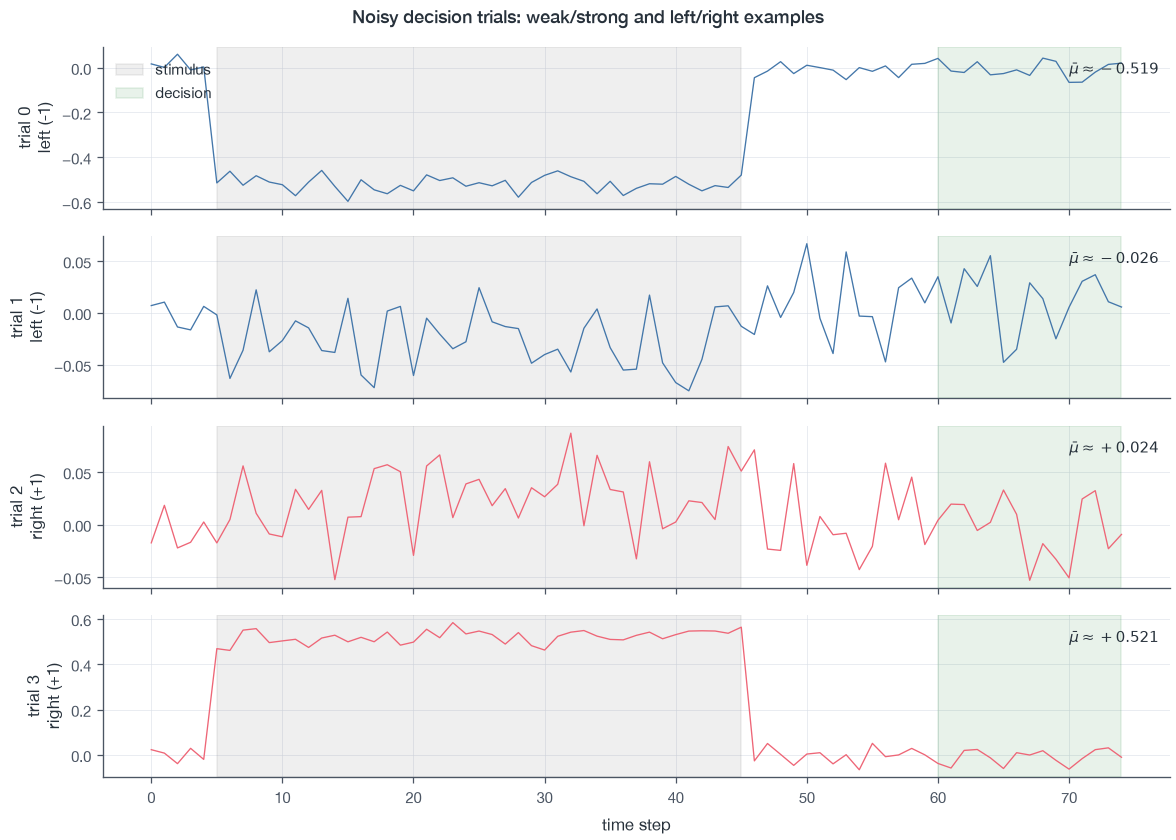

Allowed signed strengths: [-0.512 -0.256 -0.128 -0.064 -0.032  0.032  0.064  0.128  0.256  0.512]
Input shape: (80, 75) label shape: (80,)


In [2]:
preview_inputs, preview_labels = generate_perceptual_decision_making_trials(
    num_trials=80,
    rng=np.random.default_rng(BASE_SEED),
)
stimulus_mean = preview_inputs[:, STIMULUS_WINDOW[0] : STIMULUS_WINDOW[1] + 1].mean(
    axis=1
)

negative = np.flatnonzero(preview_labels < 0)
positive = np.flatnonzero(preview_labels > 0)
preview_indices = np.array(
    [
        negative[np.argmin(stimulus_mean[negative])],
        negative[np.argmax(stimulus_mean[negative])],
        positive[np.argmin(stimulus_mean[positive])],
        positive[np.argmax(stimulus_mean[positive])],
    ]
)

fig, axes = plot_first_perceptual_decision_making_trials(
    preview_inputs[preview_indices],
    preview_labels[preview_indices],
    num_trials=len(preview_indices),
)
for axis, mean_value in zip(axes, stimulus_mean[preview_indices]):
    axis.axvspan(TRIAL_LENGTH - 15, TRIAL_LENGTH - 1, color=COLORS["green"], alpha=0.10)
    axis.text(
        0.99,
        0.83,
        rf"$\bar{{\mu}}\approx {mean_value:+.3f}$",
        transform=axis.transAxes,
        ha="right",
        fontsize=9,
    )
axes[0].legend(
    handles=(
        Patch(color="gray", alpha=0.12, label="stimulus"),
        Patch(color=COLORS["green"], alpha=0.10, label="decision"),
    ),
    loc="upper left",
)
fig.suptitle("Noisy decision trials: weak/strong and left/right examples")
plt.show()

print("Allowed signed strengths:", np.round(np.sort(STIMULUS_STRENGTHS), 3))
print("Input shape:", preview_inputs.shape, "label shape:", preview_labels.shape)

### 1.2 Train the shared model at rank one

The low-rank multiplication is performed as
\(m[n^\top\phi(x)/N]\), so the code never materializes the \(N\times N\)
recurrent matrix. Training minimizes MSE only over the final 15 steps,
with Adam, learning rate \(5\times10^{-3}\), and batches of 32.

The repository helper calls one pass over the fixed training set an *epoch*.
Because there are several batches per epoch, the number of optimizer updates is
`epochs × ceil(num_trials / batch_size)`.

In [3]:
RANK1_DECISION_STEPS = 15
RANK1_TRAIN_TRIALS = 200
RANK1_EPOCHS = 300
BATCH_SIZE = 32
LEARNING_RATE = 5e-3

rank1_train_inputs, rank1_train_labels = generate_perceptual_decision_making_trials(
    num_trials=RANK1_TRAIN_TRIALS,
    rng=np.random.default_rng(BASE_SEED + 1),
)
rank1_test_inputs, rank1_test_labels = generate_perceptual_decision_making_trials(
    num_trials=256,
    rng=np.random.default_rng(BASE_SEED + 2),
)

torch.manual_seed(BASE_SEED)
rank1_model = LowRankRNN(n_units=NUM_UNITS, rank=1)
fixed_input_before = rank1_model.I.clone()
fixed_readout_before = rank1_model.w.clone()
rank1_losses = train_model(
    rank1_model,
    torch.as_tensor(rank1_train_inputs, dtype=torch.float32),
    torch.as_tensor(rank1_train_labels, dtype=torch.float32),
    epochs=RANK1_EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    decision_steps=RANK1_DECISION_STEPS,
    log_every=100,
)

rank1_outputs, rank1_states = run_model(rank1_model, rank1_test_inputs)
rank1_decisions = decision_values(rank1_outputs, RANK1_DECISION_STEPS)
rank1_test_mse = float(np.mean((rank1_decisions - rank1_test_labels) ** 2))
rank1_accuracy = float(
    np.mean(np.where(rank1_decisions >= 0, 1, -1) == rank1_test_labels)
)
rank1_updates = RANK1_EPOCHS * ceil(RANK1_TRAIN_TRIALS / BATCH_SIZE)

assert rank1_losses[-1] < 5e-2
assert torch.equal(rank1_model.I, fixed_input_before)
assert torch.equal(rank1_model.w, fixed_readout_before)

print(f"Optimizer updates:      {rank1_updates}")
print(f"Final training loss:    {rank1_losses[-1]:.6f}  (target < 0.05)")
print(f"Held-out decision MSE: {rank1_test_mse:.6f}")
print(f"Held-out sign accuracy:{rank1_accuracy:8.1%}")

Epoch 100: loss=0.000300


Epoch 200: loss=0.000121


Epoch 300: loss=0.000088
Optimizer updates:      2100
Final training loss:    0.000088  (target < 0.05)
Held-out decision MSE: 0.000048
Held-out sign accuracy:  100.0%


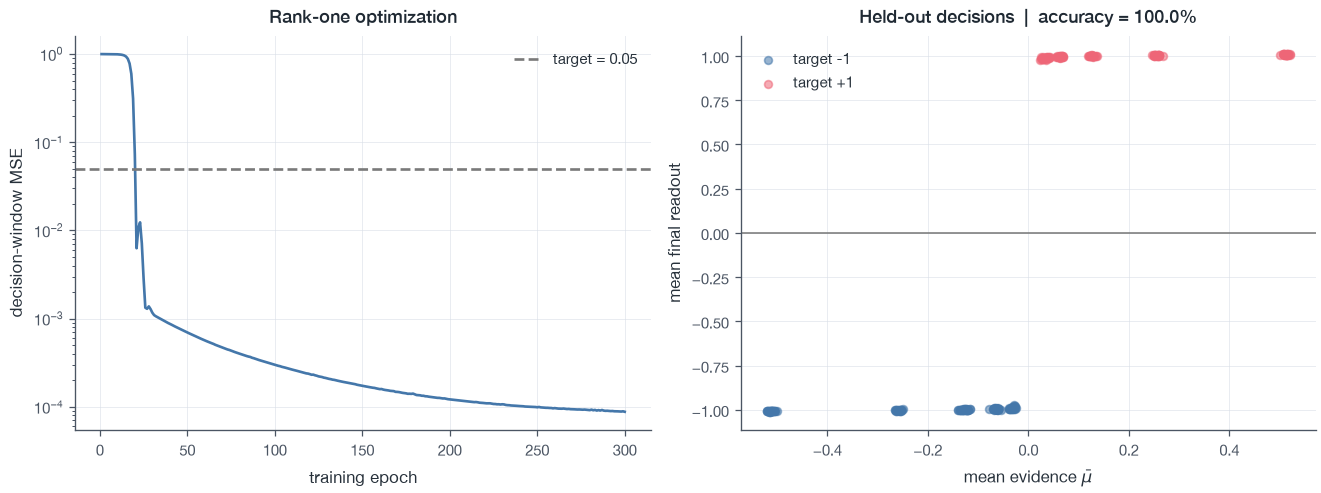

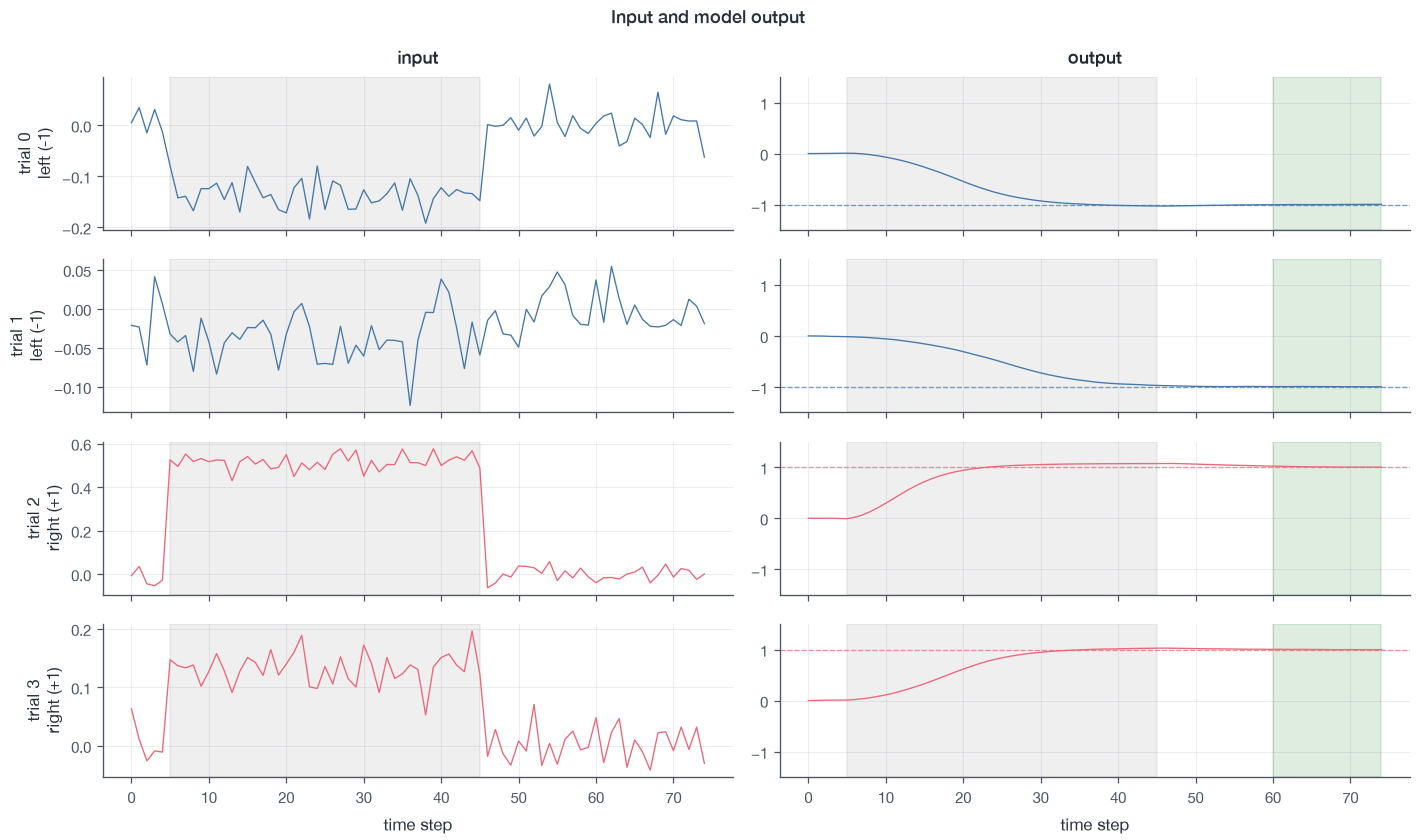

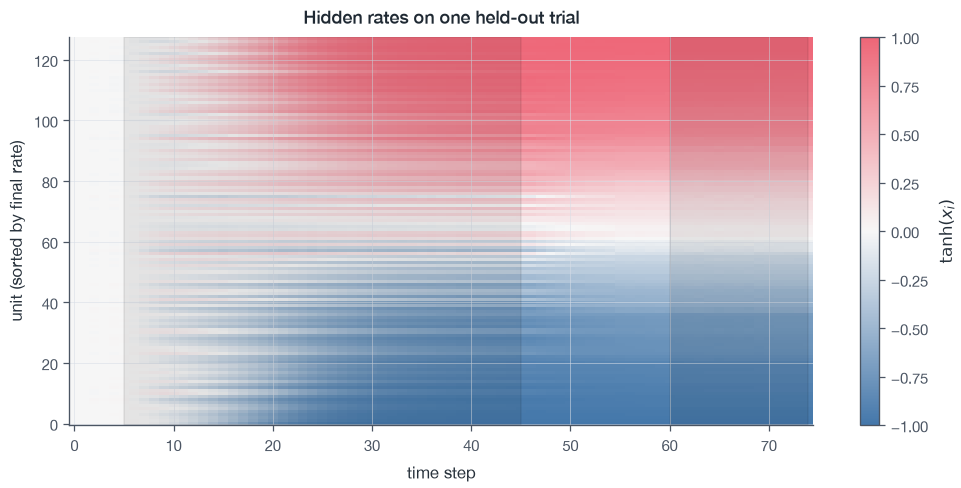

In [4]:
stimulus_estimates = rank1_test_inputs[
    :, STIMULUS_WINDOW[0] : STIMULUS_WINDOW[1] + 1
].mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.1), constrained_layout=True)
axes[0].semilogy(np.arange(1, len(rank1_losses) + 1), rank1_losses)
axes[0].axhline(5e-2, color=COLORS["gray"], linestyle="--", label="target = 0.05")
axes[0].set(
    xlabel="training epoch",
    ylabel="decision-window MSE",
    title="Rank-one optimization",
)
axes[0].legend()

for choice, color in CHOICE_COLORS.items():
    mask = rank1_test_labels == choice
    axes[1].scatter(
        stimulus_estimates[mask],
        rank1_decisions[mask],
        s=22,
        alpha=0.55,
        color=color,
        label=f"target {choice:+d}",
    )
axes[1].axhline(0, color="0.45", linewidth=0.9)
axes[1].set(
    xlabel=r"mean evidence $\bar{\mu}$",
    ylabel="mean final readout",
    title=f"Held-out decisions  |  accuracy = {rank1_accuracy:.1%}",
)
axes[1].legend()
plt.show()

positive_examples = np.flatnonzero(rank1_test_labels > 0)[:2]
negative_examples = np.flatnonzero(rank1_test_labels < 0)[:2]
rank1_examples = np.concatenate((negative_examples, positive_examples))
plot_trial_outputs(
    rank1_test_inputs[rank1_examples],
    rank1_test_labels[rank1_examples],
    rank1_outputs[rank1_examples],
    decision_steps=RANK1_DECISION_STEPS,
)
plt.show()

example = rank1_examples[0]
example_rates = np.tanh(rank1_states[example])
unit_order = np.argsort(example_rates[-1])
fig, axis = plt.subplots(figsize=(10, 4.2))
image = axis.imshow(
    example_rates[:, unit_order].T,
    aspect="auto",
    origin="lower",
    cmap=SIGNED_VALUE_CMAP,
    norm=TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1),
)
axis.axvspan(*STIMULUS_WINDOW, color="black", alpha=0.07)
axis.axvspan(TRIAL_LENGTH - RANK1_DECISION_STEPS, TRIAL_LENGTH - 1, color="black", alpha=0.07)
axis.set(
    xlabel="time step",
    ylabel="unit (sorted by final rate)",
    title="Hidden rates on one held-out trial",
)
fig.colorbar(image, ax=axis, label=r"$\tanh(x_i)$")
plt.show()

### 1.3 Connectivity explains the computation

A neuron is one point in four-dimensional loading space
\((I,n,m,w)\). Three cross-covariances form the useful path:

1. \(\operatorname{Cov}(n,I)\) routes the input into the recurrent latent.
2. \(\operatorname{Cov}(m,n)\) feeds that latent back into itself.
3. \(\operatorname{Cov}(m,w)\) maps the recurrent state to the output.

The signs of the first and third terms may both flip: replacing
\(m\to-m,\ n\to-n\) leaves \(J=mn^\top/N\) unchanged. The invariant story
is therefore the complete input → recurrence → readout path, not one
loading vector's sign.

For comparison, the handout's paper circuit uses
\(\sigma_{mn}=1.4,\sigma_{nI}=2.6,\sigma_{mw}=2.1\). After the harmless
simultaneous sign flip of \(m,n\), this run has approximately
\((1.59,0.65,2.04)\): the recurrent and readout couplings closely match,
while its fitted input coupling is weaker.

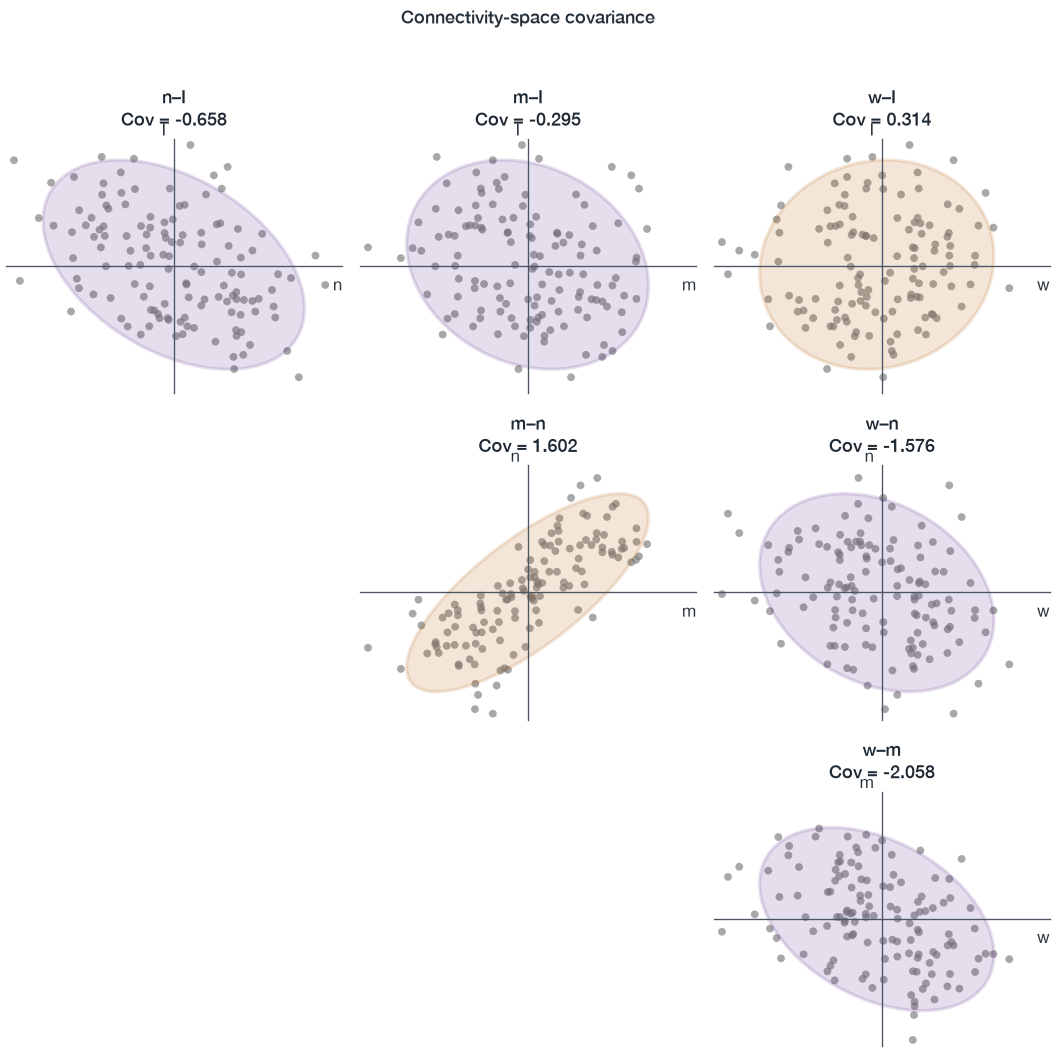

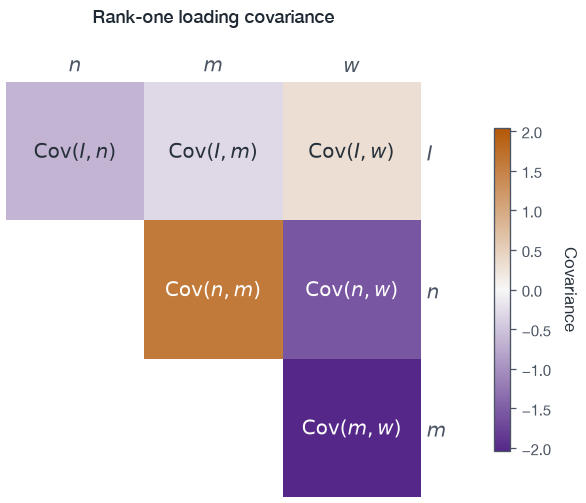

{'Cov(n, I)': -0.6531196302377552,
 'Cov(m, n)': 1.58964165924347,
 'Cov(m, w)': -2.042173281209281}

In [5]:
rank1_vectors = connectivity_vectors(rank1_model)
rank1_names = tuple(rank1_vectors)
rank1_loading_mean, rank1_loading_covariance = fit_loading_gaussian(rank1_vectors)
rank1_index = {name: index for index, name in enumerate(rank1_names)}

plot_connectivity_pairs(
    rank1_vectors,
    row_names=("I", "n", "m"),
    column_names=("n", "m", "w"),
)
plt.show()
figure, axis = plot_connectivity_covariance(
    rank1_names,
    rank1_loading_covariance,
)
axis.set_title("Rank-one loading covariance", pad=18)
plt.show()

def loading_covariance(covariance, index, first, second):
    return float(covariance[index[first], index[second]])

rank1_couplings = {
    "Cov(n, I)": loading_covariance(
        rank1_loading_covariance, rank1_index, "n", "I"
    ),
    "Cov(m, n)": loading_covariance(
        rank1_loading_covariance, rank1_index, "m", "n"
    ),
    "Cov(m, w)": loading_covariance(
        rank1_loading_covariance, rank1_index, "m", "w"
    ),
}
rank1_couplings

### 1.4 Is a four-dimensional Gaussian sufficient?

We fit one multivariate Gaussian to the 128 neuron rows, redraw complete
networks from that distribution, and test them without further training.
Matching a covariance *in expectation* need not give identical finite-\(N\)
behavior, especially near a bifurcation.

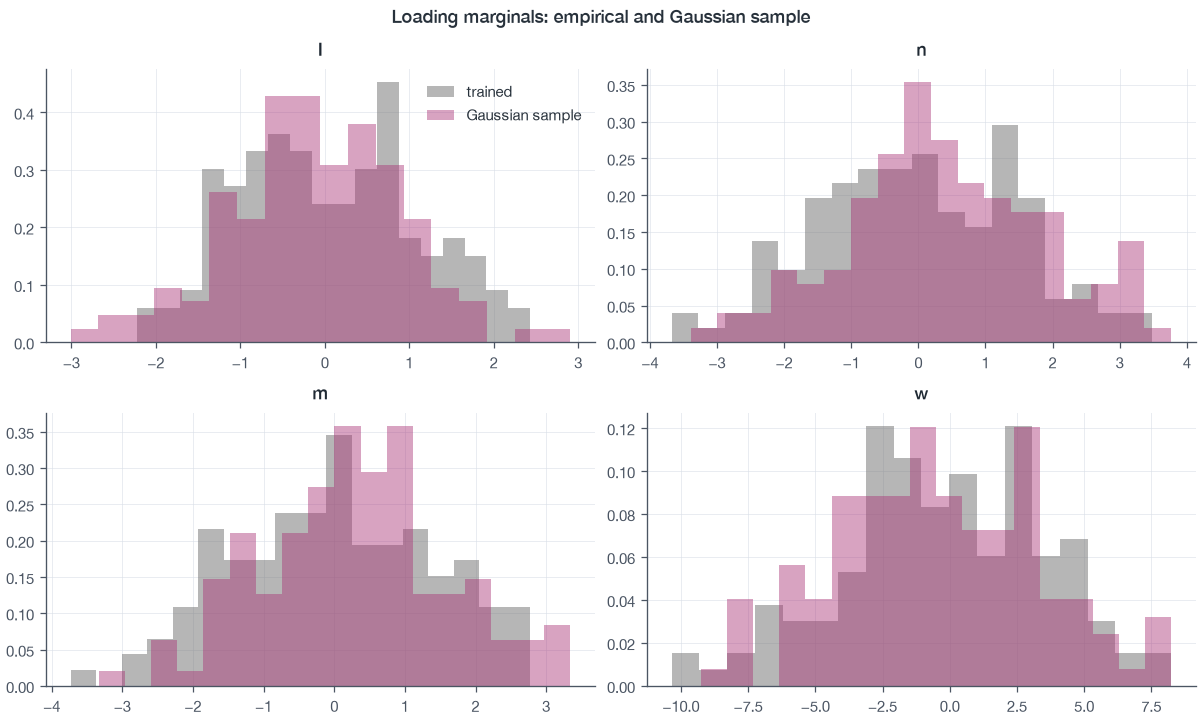

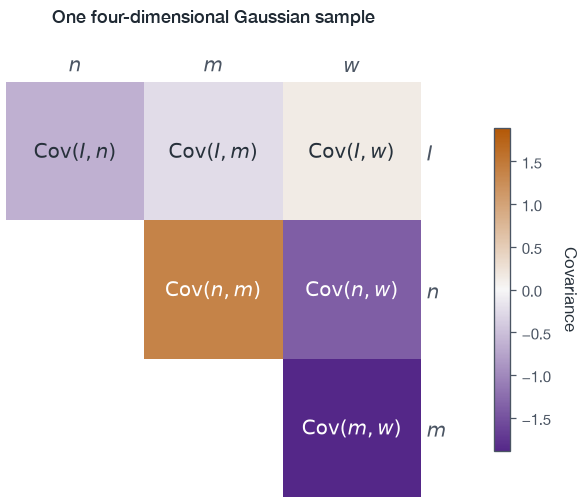

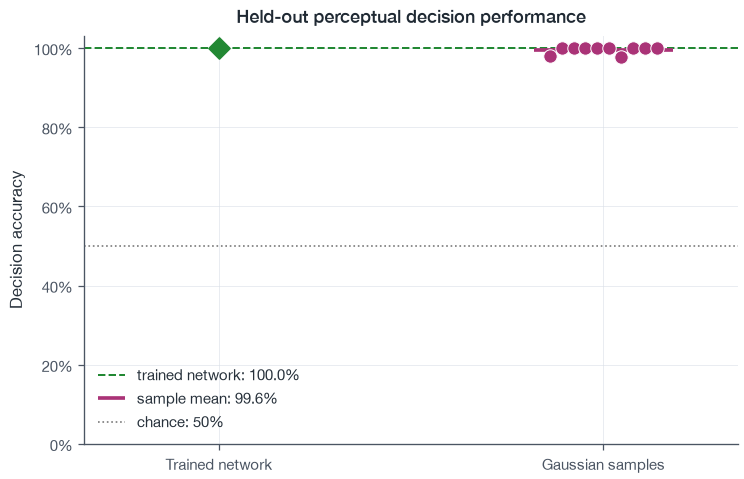

One-sample relative covariance error: 4.2%
Gaussian-network accuracy, mean [range]: 99.6% [97.7%, 100.0%]


In [6]:
rank1_gaussian_rng = np.random.default_rng(BASE_SEED + 10)
rank1_sampled_loadings = sample_loading_gaussian(
    rank1_loading_mean,
    rank1_loading_covariance,
    num_samples=NUM_UNITS,
    rng=rank1_gaussian_rng,
)
rank1_sampled_vectors = {
    name: rank1_sampled_loadings[:, index]
    for index, name in enumerate(rank1_names)
}
_, rank1_sampled_covariance = fit_loading_gaussian(rank1_sampled_vectors)

fig, axes = plt.subplots(2, 2, figsize=(10, 6), constrained_layout=True)
for axis, name in zip(axes.flat, rank1_names):
    axis.hist(
        rank1_vectors[name],
        bins=18,
        density=True,
        alpha=0.55,
        color=COLORS["gray"],
        label="trained",
    )
    axis.hist(
        rank1_sampled_vectors[name],
        bins=18,
        density=True,
        alpha=0.45,
        color=COLORS["purple"],
        label="Gaussian sample",
    )
    axis.set_title(name)
axes[0, 0].legend()
fig.suptitle("Loading marginals: empirical and Gaussian sample")
plt.show()

figure, axis = plot_connectivity_covariance(
    rank1_names,
    rank1_sampled_covariance,
)
axis.set_title("One four-dimensional Gaussian sample", pad=18)
plt.show()

rank1_sampled_networks = sample_low_rank_rnns(
    rank1_names,
    rank1_loading_mean,
    rank1_loading_covariance,
    num_networks=10,
    num_neurons=NUM_UNITS,
    rng=np.random.default_rng(BASE_SEED + 11),
)
rank1_sampled_accuracies = np.array(
    [
        decision_accuracy(
            network,
            torch.as_tensor(rank1_test_inputs, dtype=torch.float32),
            torch.as_tensor(rank1_test_labels),
            decision_steps=RANK1_DECISION_STEPS,
        )
        for network in rank1_sampled_networks
    ]
)
plot_accuracy_comparison(rank1_accuracy, rank1_sampled_accuracies)
plt.show()

rank1_covariance_error = np.linalg.norm(
    rank1_sampled_covariance - rank1_loading_covariance
) / np.linalg.norm(rank1_loading_covariance)
print(f"One-sample relative covariance error: {rank1_covariance_error:.1%}")
print(
    "Gaussian-network accuracy, mean [range]: "
    f"{rank1_sampled_accuracies.mean():.1%} "
    f"[{rank1_sampled_accuracies.min():.1%}, {rank1_sampled_accuracies.max():.1%}]"
)

### 1.5 The population activity is two-dimensional

Starting from \(x(0)=0\), every drive lies in
\(\operatorname{span}\{m,I\}\): recurrence points along \(m\), input points
along \(I\), and leak cannot create a new direction. The trajectories should
therefore move with the stimulus and then separate by choice.

If \(m\) and \(I\) were unknown—as in a generic RNN or neural recording—we
would stack states across trials and use PCA (or factor analysis for noisy
experimental data) to discover the dominant subspace.

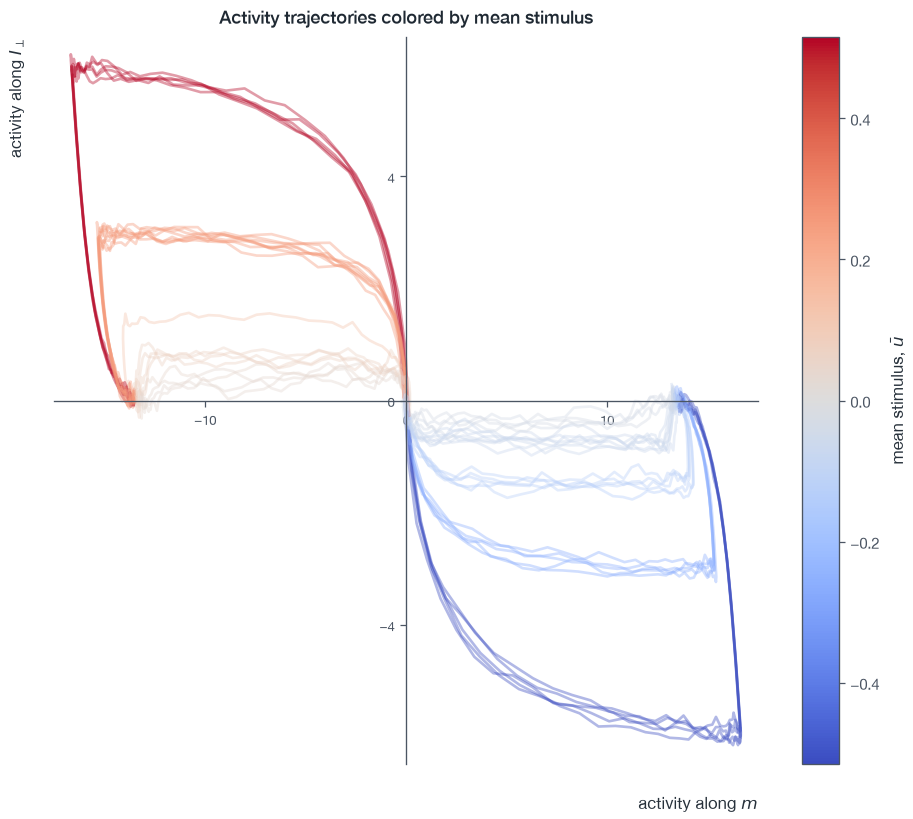

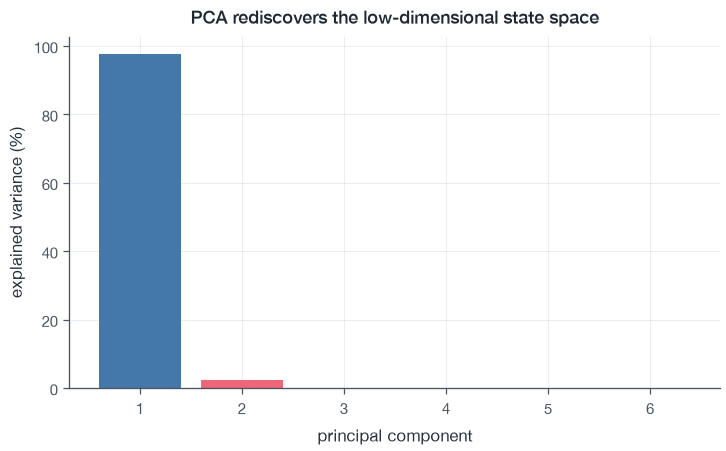

Variance explained by the first two PCs: 100.00%


In [7]:
rank1_projected = project_rank_one_activity(
    torch.as_tensor(rank1_states, dtype=torch.float32),
    rank1_model,
)
trajectory_subset = np.linspace(0, len(rank1_projected) - 1, 48, dtype=int)
plot_activity_trajectories_by_stimulus(
    rank1_projected[trajectory_subset],
    stimulus_estimates[trajectory_subset],
)
plt.show()

activity_matrix = rank1_states.reshape(-1, NUM_UNITS)
centered_activity = activity_matrix - activity_matrix.mean(axis=0, keepdims=True)
_, singular_values, _ = np.linalg.svd(centered_activity, full_matrices=False)
explained_variance = singular_values**2 / np.sum(singular_values**2)

fig, axis = plt.subplots(figsize=(7, 3.8))
axis.bar(
    np.arange(1, 7),
    100 * explained_variance[:6],
    color=(COLORS["blue"], COLORS["red"], *([COLORS["gray"]] * 4)),
)
axis.set(
    xlabel="principal component",
    ylabel="explained variance (%)",
    title="PCA rediscovers the low-dimensional state space",
)
plt.show()
print(f"Variance explained by the first two PCs: {explained_variance[:2].sum():.2%}")

### 1.6 A rank-generic Gaussian equivalent circuit

For jointly Gaussian loadings and
\(x_i\approx I_i v+\sum_r m_{ir}\kappa_r\), Stein's lemma gives

\[
\dot\kappa
=-\kappa+\mu_n\langle\tanh h\rangle
+\operatorname{Cov}(n,h)\langle\operatorname{sech}^2h\rangle,
\qquad
\dot v=-v+u,
\]

with the analogous expression for \(z\) using \(w\). For zero means and
orthogonal rank-one loadings this reduces to the handout:

\[
\dot\kappa=-\kappa+g(\Delta)
[\sigma_{mn}\kappa+\sigma_{nI}v],
\quad
\Delta^2=\sigma_m^2\kappa^2+\sigma_I^2v^2.
\]

Because the empirical circuit succeeds, we do not substitute the paper values.
If that fallback were needed, the handout leaves \(\sigma_m\) unspecified;
we would state the extra convention \(\sigma_m=1\) rather than guess silently.

The helper below keeps the full fitted means and covariance, and works
unchanged for rank two.

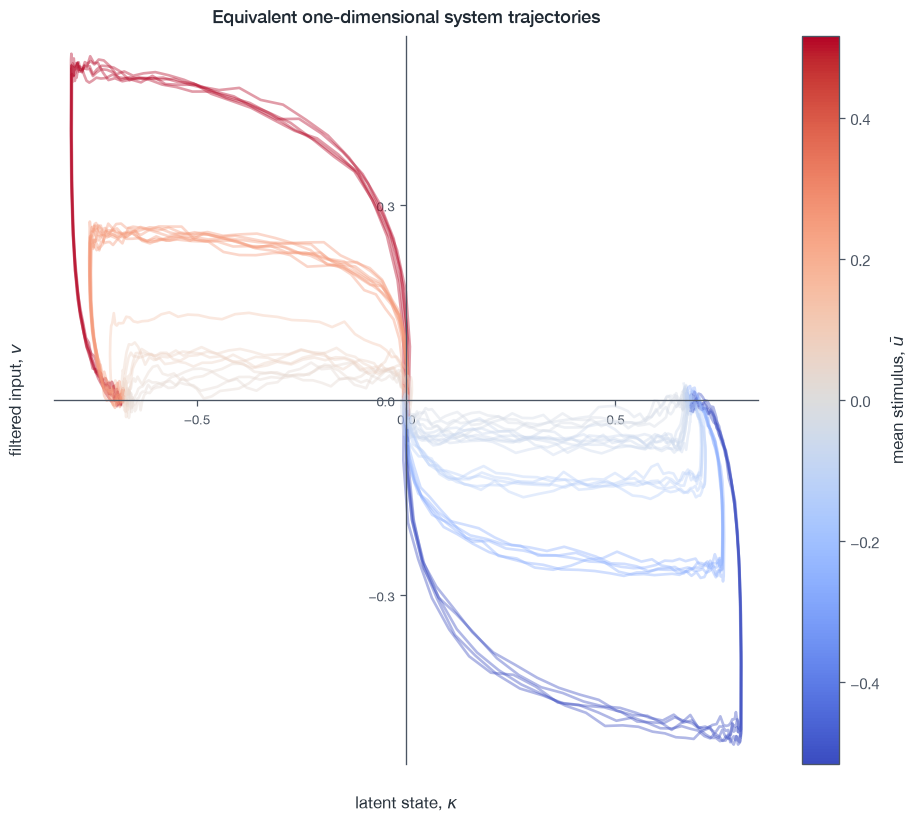

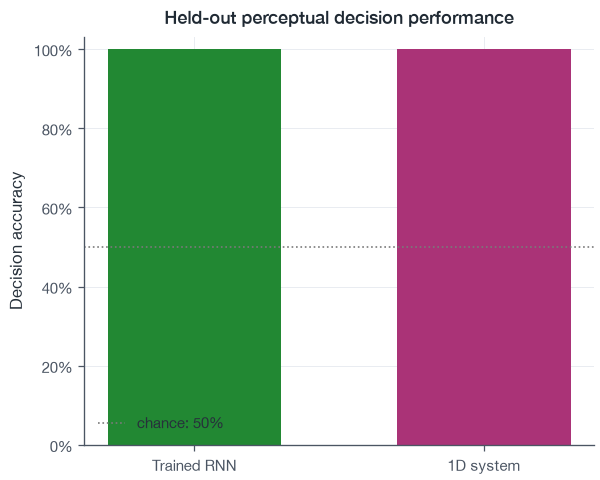

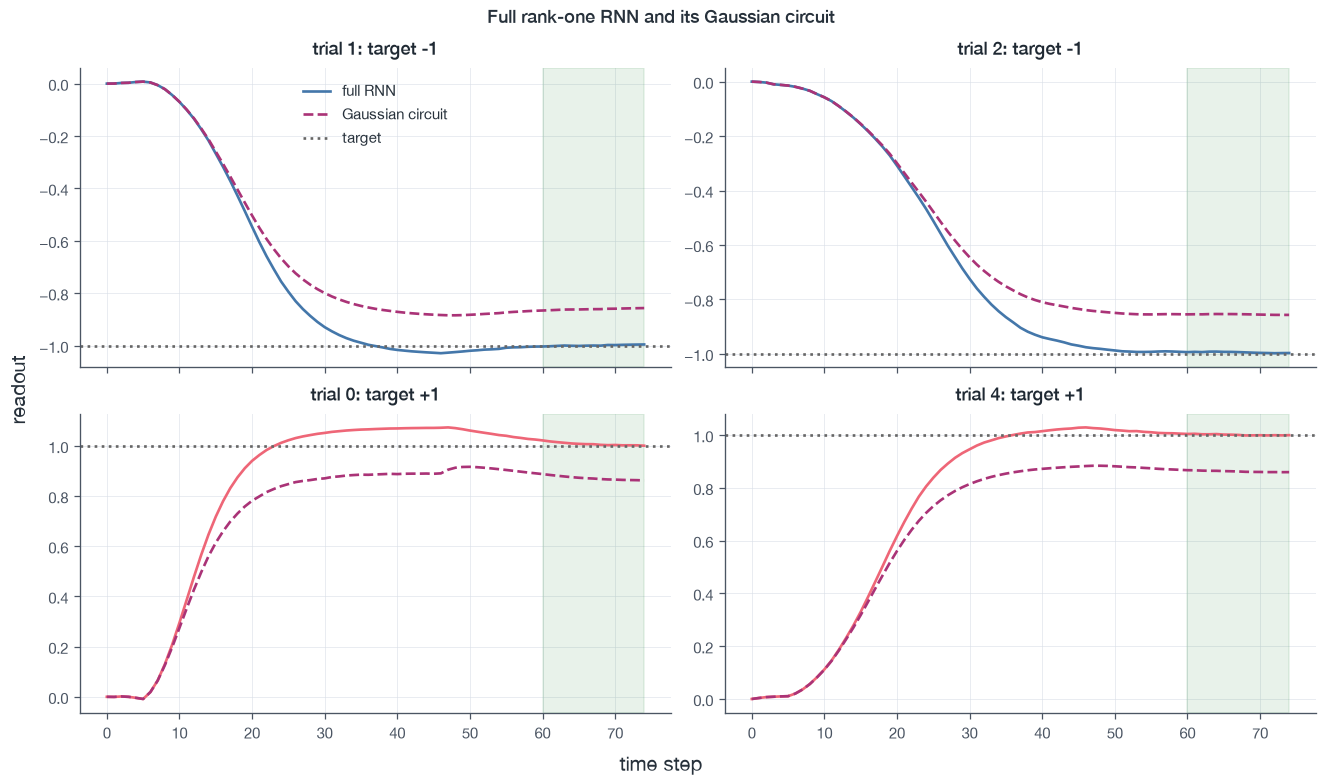

Gaussian-circuit sign accuracy: 100.0%


In [8]:
quadrature_nodes, quadrature_weights = hermgauss(40)
standard_normal_nodes = np.sqrt(2) * quadrature_nodes
standard_normal_weights = quadrature_weights / np.sqrt(np.pi)


def gaussian_rate_moments(coefficients, mean, covariance, basis_indices):
    '''E[tanh(h)] and E[sech²(h)] for h = loading · coefficients.'''
    coefficients = np.atleast_2d(np.asarray(coefficients, dtype=float))
    basis_mean = mean[basis_indices]
    basis_covariance = covariance[np.ix_(basis_indices, basis_indices)]
    current_mean = coefficients @ basis_mean
    current_variance = np.einsum(
        "bi,ij,bj->b",
        coefficients,
        basis_covariance,
        coefficients,
    )
    currents = current_mean[:, None] + np.sqrt(
        np.maximum(current_variance, 0)
    )[:, None] * standard_normal_nodes
    rates = np.tanh(currents)
    return (
        rates @ standard_normal_weights,
        (1 - rates**2) @ standard_normal_weights,
    )


def simulate_gaussian_circuit(inputs, names, mean, covariance, step_size):
    '''Simulate the Gaussian mean-field circuit for any low rank.'''
    inputs = np.asarray(inputs, dtype=float)
    names = tuple(names)
    rank = max((len(names) - 2) // 2, 1)
    n_indices = np.arange(1, 1 + rank)
    m_indices = np.arange(1 + rank, 1 + 2 * rank)
    input_index = 0
    readout_index = len(names) - 1
    basis_indices = np.array((input_index, *m_indices))

    batch_size, num_steps = inputs.shape
    kappa = np.zeros((batch_size, rank))
    filtered_input = np.zeros(batch_size)
    outputs = np.empty((batch_size, num_steps))
    kappa_history = np.empty((batch_size, num_steps, rank))
    filtered_history = np.empty((batch_size, num_steps))

    for time in range(num_steps):
        kappa_history[:, time] = kappa
        filtered_history[:, time] = filtered_input
        coefficients = np.column_stack((filtered_input, kappa))
        mean_rate, mean_gain = gaussian_rate_moments(
            coefficients,
            mean,
            covariance,
            basis_indices,
        )

        cov_n_current = (
            covariance[np.ix_(n_indices, basis_indices)] @ coefficients.T
        ).T
        recurrent_drive = (
            mean[n_indices][None, :] * mean_rate[:, None]
            + cov_n_current * mean_gain[:, None]
        )

        cov_w_current = (
            covariance[readout_index, basis_indices] * coefficients
        ).sum(axis=1)
        outputs[:, time] = (
            mean[readout_index] * mean_rate + cov_w_current * mean_gain
        )

        kappa += step_size * (-kappa + recurrent_drive)
        filtered_input += step_size * (
            -filtered_input + inputs[:, time]
        )

    return outputs, kappa_history, filtered_history


rank1_reduced_outputs, rank1_reduced_kappa, rank1_filtered_input = (
    simulate_gaussian_circuit(
        rank1_test_inputs,
        rank1_names,
        rank1_loading_mean,
        rank1_loading_covariance,
        rank1_model.step_size,
    )
)
rank1_reduced_decisions = decision_values(
    rank1_reduced_outputs,
    RANK1_DECISION_STEPS,
)
rank1_reduced_accuracy = float(
    np.mean(
        np.where(rank1_reduced_decisions >= 0, 1, -1) == rank1_test_labels
    )
)

reduced_trajectories = np.dstack(
    (rank1_reduced_kappa[..., 0], rank1_filtered_input)
)
plot_reduced_system_trajectories(
    reduced_trajectories[trajectory_subset],
    stimulus_estimates[trajectory_subset],
)
plt.show()
plot_reduced_system_accuracy(rank1_accuracy, rank1_reduced_accuracy)
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(11, 6.5), sharex=True, constrained_layout=True)
for axis, trial in zip(axes.flat, rank1_examples):
    color = CHOICE_COLORS[int(rank1_test_labels[trial])]
    axis.plot(rank1_outputs[trial], color=color, label="full RNN")
    axis.plot(rank1_reduced_outputs[trial], color=COLORS["purple"], linestyle="--", label="Gaussian circuit")
    axis.axhline(rank1_test_labels[trial], color="0.4", linestyle=":", label="target")
    axis.axvspan(TRIAL_LENGTH - RANK1_DECISION_STEPS, TRIAL_LENGTH - 1, color=COLORS["green"], alpha=0.10)
    axis.set_title(f"trial {trial}: target {rank1_test_labels[trial]:+d}")
axes[0, 0].legend()
fig.supxlabel("time step")
fig.supylabel("readout")
fig.suptitle("Full rank-one RNN and its Gaussian circuit")
plt.show()

print(f"Gaussian-circuit sign accuracy: {rank1_reduced_accuracy:.1%}")

### 1.7 Fixed points reveal a categorical memory

At zero input, define the one-dimensional flow \(f(\kappa)=\dot\kappa\)
and energy \(q(\kappa)=f(\kappa)^2/2\). We minimize \(q\) from every local
basin on a dense grid, verify \(f\approx0\), and classify each root by the
slope \(f'(\kappa)\): negative is stable, positive is unstable.

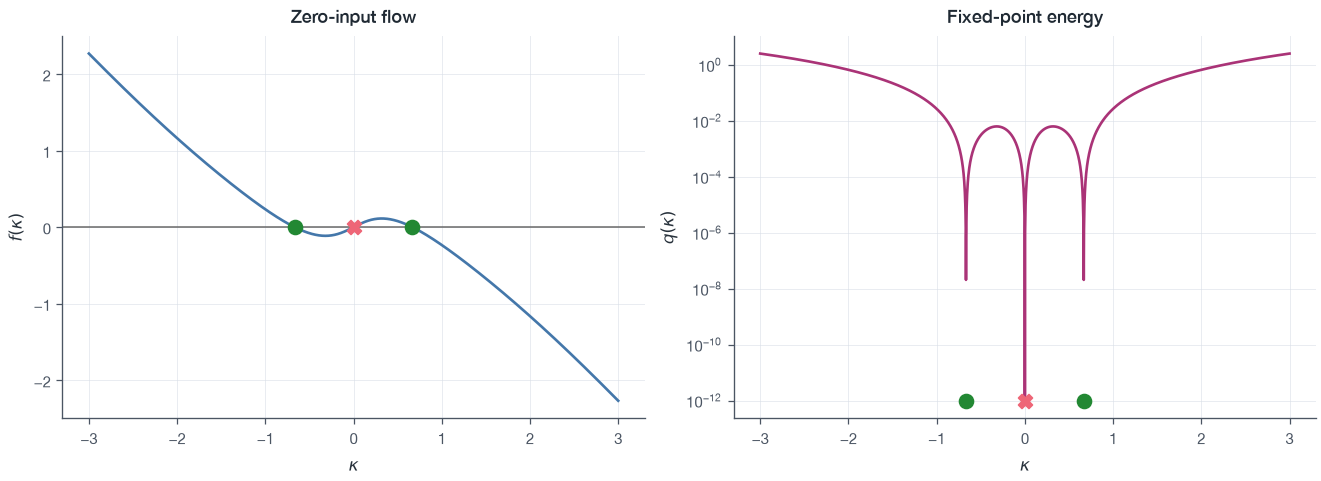

kappa=-0.6671  slope=-0.572  stable
kappa=-0.0000  slope=+0.590  unstable
kappa=+0.6671  slope=-0.572  stable


In [9]:
rank1_n_index = rank1_index["n"]
rank1_basis_indices = np.array((rank1_index["I"], rank1_index["m"]))


def rank1_flow(kappa_values):
    kappa_values = np.atleast_1d(np.asarray(kappa_values, dtype=float))
    coefficients = np.column_stack((np.zeros_like(kappa_values), kappa_values))
    mean_rate, mean_gain = gaussian_rate_moments(
        coefficients,
        rank1_loading_mean,
        rank1_loading_covariance,
        rank1_basis_indices,
    )
    cov_n_current = (
        rank1_loading_covariance[
            rank1_n_index,
            rank1_basis_indices,
        ]
        * coefficients
    ).sum(axis=1)
    recurrent_drive = (
        rank1_loading_mean[rank1_n_index] * mean_rate
        + cov_n_current * mean_gain
    )
    return -kappa_values + recurrent_drive


kappa_grid = np.linspace(-3.0, 3.0, 2401)
flow_grid = rank1_flow(kappa_grid)
energy_grid = 0.5 * flow_grid**2
local_minima = np.flatnonzero(
    (energy_grid[1:-1] <= energy_grid[:-2])
    & (energy_grid[1:-1] <= energy_grid[2:])
) + 1

fixed_points = []
for index in local_minima:
    result = minimize_scalar(
        lambda value: 0.5 * float(rank1_flow([value])[0]) ** 2,
        bounds=(kappa_grid[index - 1], kappa_grid[index + 1]),
        method="bounded",
    )
    if result.fun < 1e-10 and not any(
        abs(result.x - existing) < 1e-3 for existing in fixed_points
    ):
        fixed_points.append(float(result.x))
fixed_points = np.array(sorted(fixed_points))

derivative_step = 1e-4
fixed_point_slopes = np.array(
    [
        (
            rank1_flow([point + derivative_step])[0]
            - rank1_flow([point - derivative_step])[0]
        )
        / (2 * derivative_step)
        for point in fixed_points
    ]
)
fixed_point_stability = np.where(fixed_point_slopes < 0, "stable", "unstable")

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
axes[0].plot(kappa_grid, flow_grid, color=COLORS["blue"])
axes[0].axhline(0, color="0.4", linewidth=0.9)
axes[0].set(xlabel=r"$\kappa$", ylabel=r"$f(\kappa)$", title="Zero-input flow")
axes[1].semilogy(kappa_grid, energy_grid + 1e-12, color=COLORS["purple"])
axes[1].set(xlabel=r"$\kappa$", ylabel=r"$q(\kappa)$", title="Fixed-point energy")

for point, stability in zip(fixed_points, fixed_point_stability):
    color = COLORS["green"] if stability == "stable" else COLORS["red"]
    marker = "o" if stability == "stable" else "X"
    axes[0].scatter(point, 0, color=color, marker=marker, s=70, zorder=3)
    axes[1].scatter(point, 1e-12, color=color, marker=marker, s=70, zorder=3)
plt.show()

for point, slope, stability in zip(
    fixed_points,
    fixed_point_slopes,
    fixed_point_stability,
):
    print(f"kappa={point:+.4f}  slope={slope:+.3f}  {stability}")

A sign decision is naturally stored by two stable choice states separated by
an unstable boundary. An exact-value integrator would be qualitatively
different: it needs a continuum of marginal fixed points—a line attractor
with \(f(\kappa)\approx0\) across a range—so every input magnitude, not only
its sign, can persist.

## 2. Rank-two parametric working memory

### 2.1 Generate two-pulse trials

Frequencies are sampled from \(\{10,14,\ldots,34\}\) Hz and mapped to

\[
u_i=\frac{f_i-22}{24},
\qquad
y=\frac{f_1-f_2}{24}=u_1-u_2.
\]

To follow the assignment literally, the first inclusive window is
\(5{:}10\), the second is \(60{:}70\), and the final five of 80 steps are
scored. These windows have unequal lengths (6 and 11 steps); we keep that
explicit rather than silently changing the endpoints.

The paper's random delays would prevent a fixed-clock solution and force
time-robust memory. More frequency values would encourage interpolation
along a continuous code rather than memorization of 49 pairs.

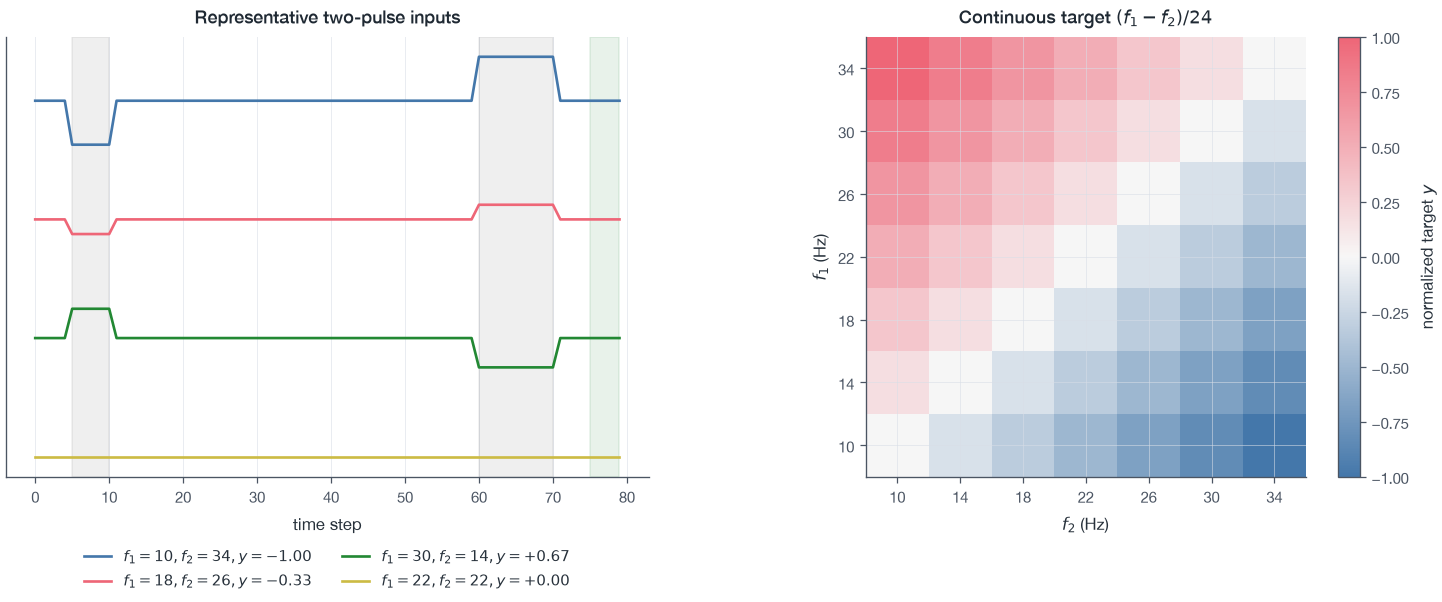

In [10]:
MEMORY_FIRST_WINDOW = (5, 10)
MEMORY_SECOND_WINDOW = (60, 70)
MEMORY_DECISION_STEPS = 5
MEMORY_TRIAL_LENGTH = 80
FREQUENCY_RANGE = float(np.ptp(FREQUENCIES))
FREQUENCY_CENTER = float((FREQUENCIES.min() + FREQUENCIES.max()) / 2)


def make_memory_trials(frequency_pairs, *, second_start=MEMORY_SECOND_WINDOW[0]):
    '''Build the exact fixed-window trials from the assignment.'''
    frequency_pairs = np.asarray(frequency_pairs, dtype=float)
    second_length = MEMORY_SECOND_WINDOW[1] - MEMORY_SECOND_WINDOW[0] + 1
    second_stop = second_start + second_length
    trial_length = second_stop + (MEMORY_TRIAL_LENGTH - MEMORY_SECOND_WINDOW[1] - 1)

    amplitudes = stimulus_amplitudes(frequency_pairs)
    inputs = np.zeros((len(frequency_pairs), trial_length), dtype=np.float32)
    inputs[
        :,
        MEMORY_FIRST_WINDOW[0] : MEMORY_FIRST_WINDOW[1] + 1,
    ] = amplitudes[:, 0, None]
    inputs[:, second_start:second_stop] = amplitudes[:, 1, None]
    targets = ((frequency_pairs[:, 0] - frequency_pairs[:, 1]) / FREQUENCY_RANGE).astype(
        np.float32
    )
    return inputs, targets


def sample_memory_trials(num_trials, rng):
    pairs = rng.choice(FREQUENCIES, size=(num_trials, 2))
    inputs, targets = make_memory_trials(pairs)
    return pairs, inputs, targets


f1_grid, f2_grid = np.meshgrid(FREQUENCIES, FREQUENCIES, indexing="ij")
memory_grid_pairs = np.column_stack((f1_grid.ravel(), f2_grid.ravel()))
memory_grid_inputs, memory_grid_targets = make_memory_trials(memory_grid_pairs)
outside_stimuli = np.ones(MEMORY_TRIAL_LENGTH, dtype=bool)
outside_stimuli[
    MEMORY_FIRST_WINDOW[0] : MEMORY_FIRST_WINDOW[1] + 1
] = False
outside_stimuli[
    MEMORY_SECOND_WINDOW[0] : MEMORY_SECOND_WINDOW[1] + 1
] = False
assert memory_grid_inputs.shape == (49, MEMORY_TRIAL_LENGTH)
assert np.all(memory_grid_inputs[:, outside_stimuli] == 0)
assert np.allclose(
    memory_grid_targets,
    stimulus_amplitudes(memory_grid_pairs)[:, 0]
    - stimulus_amplitudes(memory_grid_pairs)[:, 1],
)

example_pairs = np.array(((10, 34), (18, 26), (30, 14), (22, 22)))
example_inputs, example_targets = make_memory_trials(example_pairs)
offsets = 1.35 * np.arange(len(example_pairs))[::-1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for pair, target, trial, offset in zip(
    example_pairs,
    example_targets,
    example_inputs,
    offsets,
):
    axes[0].plot(trial + offset, label=rf"$f_1={pair[0]}, f_2={pair[1]}, y={target:+.2f}$")
axes[0].axvspan(*MEMORY_FIRST_WINDOW, color="gray", alpha=0.12)
axes[0].axvspan(*MEMORY_SECOND_WINDOW, color="gray", alpha=0.12)
axes[0].axvspan(
    MEMORY_TRIAL_LENGTH - MEMORY_DECISION_STEPS,
    MEMORY_TRIAL_LENGTH - 1,
    color=COLORS["green"],
    alpha=0.10,
)
axes[0].set(
    xlabel="time step",
    yticks=[],
    title="Representative two-pulse inputs",
)
axes[0].legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.13),
    ncol=2,
)

target_matrix = memory_grid_targets.reshape(len(FREQUENCIES), len(FREQUENCIES))
image = axes[1].imshow(
    target_matrix,
    origin="lower",
    cmap=SIGNED_VALUE_CMAP,
    norm=TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1),
)
axes[1].set_xticks(range(len(FREQUENCIES)), labels=FREQUENCIES.astype(int))
axes[1].set_yticks(range(len(FREQUENCIES)), labels=FREQUENCIES.astype(int))
axes[1].set(
    xlabel=r"$f_2$ (Hz)",
    ylabel=r"$f_1$ (Hz)",
    title=r"Continuous target $(f_1-f_2)/24$",
)
fig.colorbar(image, ax=axes[1], label="normalized target $y$")
plt.show()

### 2.2 Train rank two—and a matched rank-one control

The same `LowRankRNN` now receives `rank=2`. We score the final five steps
and require condition-balanced MSE below \(5\times10^{-3}\). A matched
rank-one control tests the claim that one scalar recurrent mode cannot both
preserve \(f_1\) and separately encode the identically presented \(f_2\) for
subtraction.

In [11]:
MEMORY_TRAIN_TRIALS = 200
MEMORY_RANK2_EPOCHS = 600
MEMORY_RANK1_EPOCHS = 300

memory_train_pairs, memory_train_inputs, memory_train_targets = sample_memory_trials(
    MEMORY_TRAIN_TRIALS,
    np.random.default_rng(BASE_SEED),
)

torch.manual_seed(BASE_SEED)
memory_model = LowRankRNN(NUM_UNITS, rank=2)
memory_rank2_losses = train_model(
    memory_model,
    torch.as_tensor(memory_train_inputs),
    torch.as_tensor(memory_train_targets),
    epochs=MEMORY_RANK2_EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    decision_steps=MEMORY_DECISION_STEPS,
    log_every=200,
)

torch.manual_seed(BASE_SEED + 1)
memory_rank1_control = LowRankRNN(NUM_UNITS, rank=1)
memory_rank1_losses = train_model(
    memory_rank1_control,
    torch.as_tensor(memory_train_inputs),
    torch.as_tensor(memory_train_targets),
    epochs=MEMORY_RANK1_EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    decision_steps=MEMORY_DECISION_STEPS,
    log_every=None,
)

memory_grid_outputs, memory_grid_states = run_model(
    memory_model,
    memory_grid_inputs,
)
memory_grid_decisions = decision_values(
    memory_grid_outputs,
    MEMORY_DECISION_STEPS,
)
memory_rank2_mse, memory_rank2_r2 = regression_metrics(
    memory_grid_decisions,
    memory_grid_targets,
)

memory_rank1_outputs, _ = run_model(
    memory_rank1_control,
    memory_grid_inputs,
)
memory_rank1_decisions = decision_values(
    memory_rank1_outputs,
    MEMORY_DECISION_STEPS,
)
memory_rank1_mse, memory_rank1_r2 = regression_metrics(
    memory_rank1_decisions,
    memory_grid_targets,
)

assert memory_rank2_mse < 5e-3
print(f"Rank-two condition-balanced MSE: {memory_rank2_mse:.6f}")
print(f"Rank-two condition-balanced R²:  {memory_rank2_r2:.4f}")
print(f"Rank-one control MSE:            {memory_rank1_mse:.6f}")

Epoch 200: loss=0.115002


Epoch 400: loss=0.004609


Epoch 600: loss=0.000548


Rank-two condition-balanced MSE: 0.000788
Rank-two condition-balanced R²:  0.9965
Rank-one control MSE:            0.112504


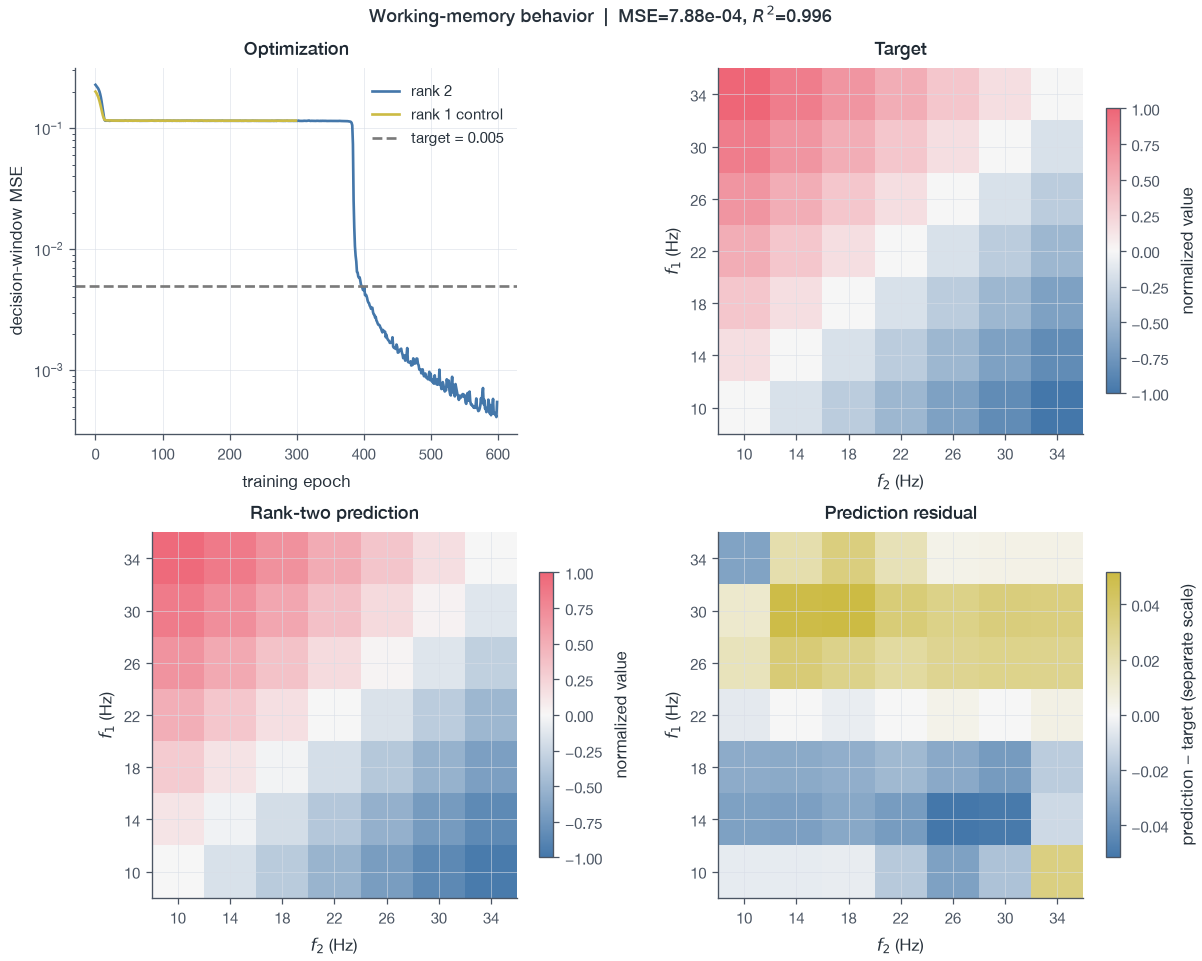

In [12]:
prediction_matrix = memory_grid_decisions.reshape(len(FREQUENCIES), len(FREQUENCIES))
residual_matrix = prediction_matrix - target_matrix
residual_limit = max(float(np.max(np.abs(residual_matrix))), 1e-3)
value_norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
residual_norm = TwoSlopeNorm(
    vmin=-residual_limit,
    vcenter=0,
    vmax=residual_limit,
)

fig, axes = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)
axes[0, 0].semilogy(
    memory_rank2_losses,
    color=COLORS["blue"],
    label="rank 2",
)
axes[0, 0].semilogy(
    memory_rank1_losses,
    color=COLORS["gold"],
    label="rank 1 control",
)
axes[0, 0].axhline(
    5e-3,
    color=COLORS["gray"],
    linestyle="--",
    label="target = 0.005",
)
axes[0, 0].set(
    xlabel="training epoch",
    ylabel="decision-window MSE",
    title="Optimization",
)
axes[0, 0].legend()

for axis, matrix, title in (
    (axes[0, 1], target_matrix, "Target"),
    (axes[1, 0], prediction_matrix, "Rank-two prediction"),
):
    value_image = axis.imshow(
        matrix,
        origin="lower",
        cmap=SIGNED_VALUE_CMAP,
        norm=value_norm,
    )
    axis.set_xticks(range(len(FREQUENCIES)), labels=FREQUENCIES.astype(int))
    axis.set_yticks(range(len(FREQUENCIES)), labels=FREQUENCIES.astype(int))
    axis.set(xlabel=r"$f_2$ (Hz)", ylabel=r"$f_1$ (Hz)", title=title)
    fig.colorbar(value_image, ax=axis, shrink=0.78, label="normalized value")

residual_axis = axes[1, 1]
residual_image = residual_axis.imshow(
    residual_matrix,
    origin="lower",
    cmap=RESIDUAL_CMAP,
    norm=residual_norm,
)
residual_axis.set_xticks(
    range(len(FREQUENCIES)),
    labels=FREQUENCIES.astype(int),
)
residual_axis.set_yticks(
    range(len(FREQUENCIES)),
    labels=FREQUENCIES.astype(int),
)
residual_axis.set(
    xlabel=r"$f_2$ (Hz)",
    ylabel=r"$f_1$ (Hz)",
    title="Prediction residual",
)
fig.colorbar(
    residual_image,
    ax=residual_axis,
    shrink=0.78,
    label="prediction − target (separate scale)",
)
fig.suptitle(
    rf"Working-memory behavior  |  MSE={memory_rank2_mse:.2e}, $R^2$={memory_rank2_r2:.3f}"
)
plt.show()

### 2.3 Put the rank-two factors in a comparable basis

Raw columns \(m_1,m_2,n_1,n_2\) have a gauge freedom:
\(M\to MA,\ N\to NA^{-\top}\) leaves \(J\) unchanged. We therefore use the
repository's SVD basis before comparing covariance patterns with the paper.

The canonical paper mechanism has one near-critical slow mode for \(f_1\), a
leakier mode for recent \(f_2\), input overlap with both, and opposite
readout overlaps so the result is \(f_1-f_2\). A finite trained network may
instead use coupled modes; the overlap matrix and trajectories below decide.

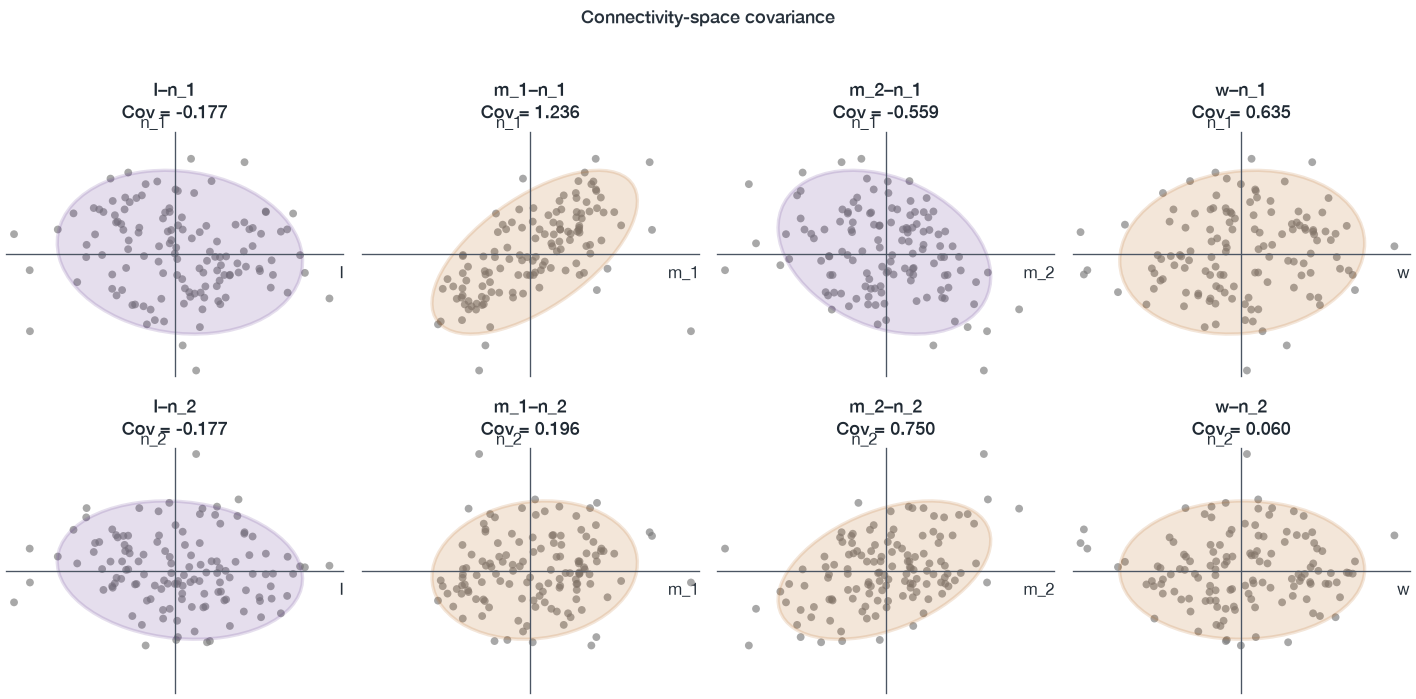

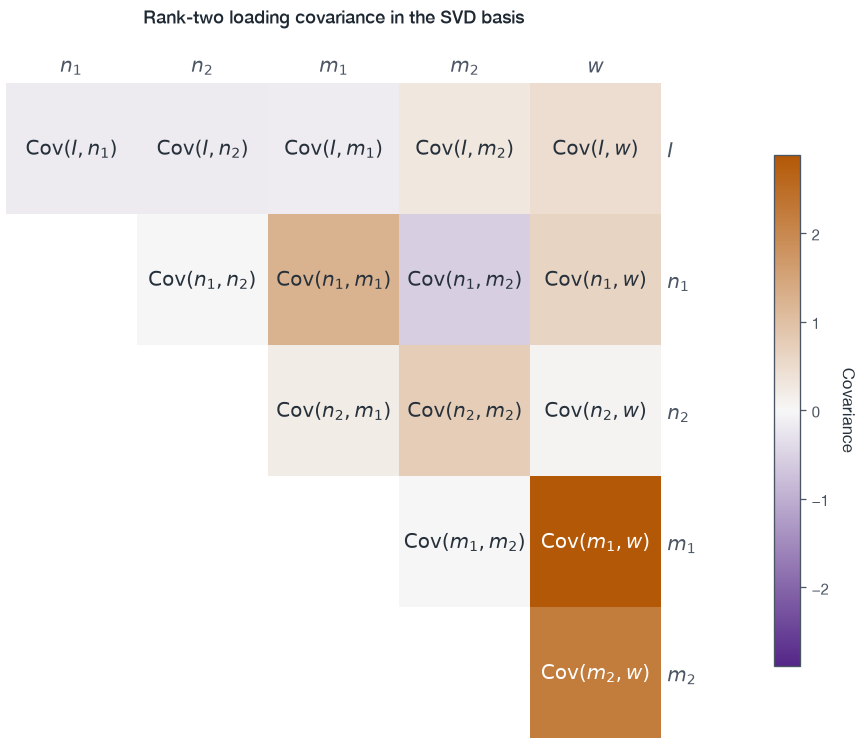

Connectivity reconstruction error: 3.13e-08
Recurrent overlap nᵀm/N:
 [[ 1.234 -0.557]
 [ 0.197  0.743]]
Small-signal overlap eigenvalues: [0.989+0.223j 0.989-0.223j]


In [13]:
canonical_m, canonical_n = svd_connectivity_basis(memory_model)
memory_canonical = deepcopy(memory_model)
with torch.no_grad():
    memory_canonical.m.copy_(
        torch.as_tensor(canonical_m, dtype=memory_canonical.m.dtype)
    )
    memory_canonical.n.copy_(
        torch.as_tensor(canonical_n, dtype=memory_canonical.n.dtype)
    )
memory_canonical.eval()

original_connectivity = (
    memory_model.m.detach().numpy() @ memory_model.n.detach().numpy().T
)
canonical_connectivity = canonical_m @ canonical_n.T
connectivity_reconstruction_error = np.linalg.norm(
    canonical_connectivity - original_connectivity
) / np.linalg.norm(original_connectivity)

memory_vectors = connectivity_vectors(memory_canonical)
memory_names = tuple(memory_vectors)
memory_loading_mean, memory_loading_covariance = fit_loading_gaussian(memory_vectors)

plot_connectivity_pairs(
    memory_vectors,
    row_names=("n_1", "n_2"),
    column_names=("I", "m_1", "m_2", "w"),
)
plt.show()
figure, axis = plot_connectivity_covariance(
    memory_names,
    memory_loading_covariance,
)
axis.set_title("Rank-two loading covariance in the SVD basis", pad=18)
plt.show()

memory_overlap = connectivity_overlap(canonical_m, canonical_n)
overlap_eigenvalues = np.linalg.eigvals(memory_overlap)
print(f"Connectivity reconstruction error: {connectivity_reconstruction_error:.2e}")
print("Recurrent overlap nᵀm/N:\n", np.round(memory_overlap, 3))
print("Small-signal overlap eigenvalues:", np.round(overlap_eigenvalues, 3))

### 2.4 Project onto the two recurrent coordinates

We recover \((\kappa_1,\kappa_2,v)\) from
\(x=M\kappa+Iv\) with a pseudoinverse. Sweeping one frequency at a time
reveals whether a coordinate is persistent, transient, or part of a coupled
trajectory. The local Jacobian during the delay supplies the corresponding
time scales without relying on visual impression alone.

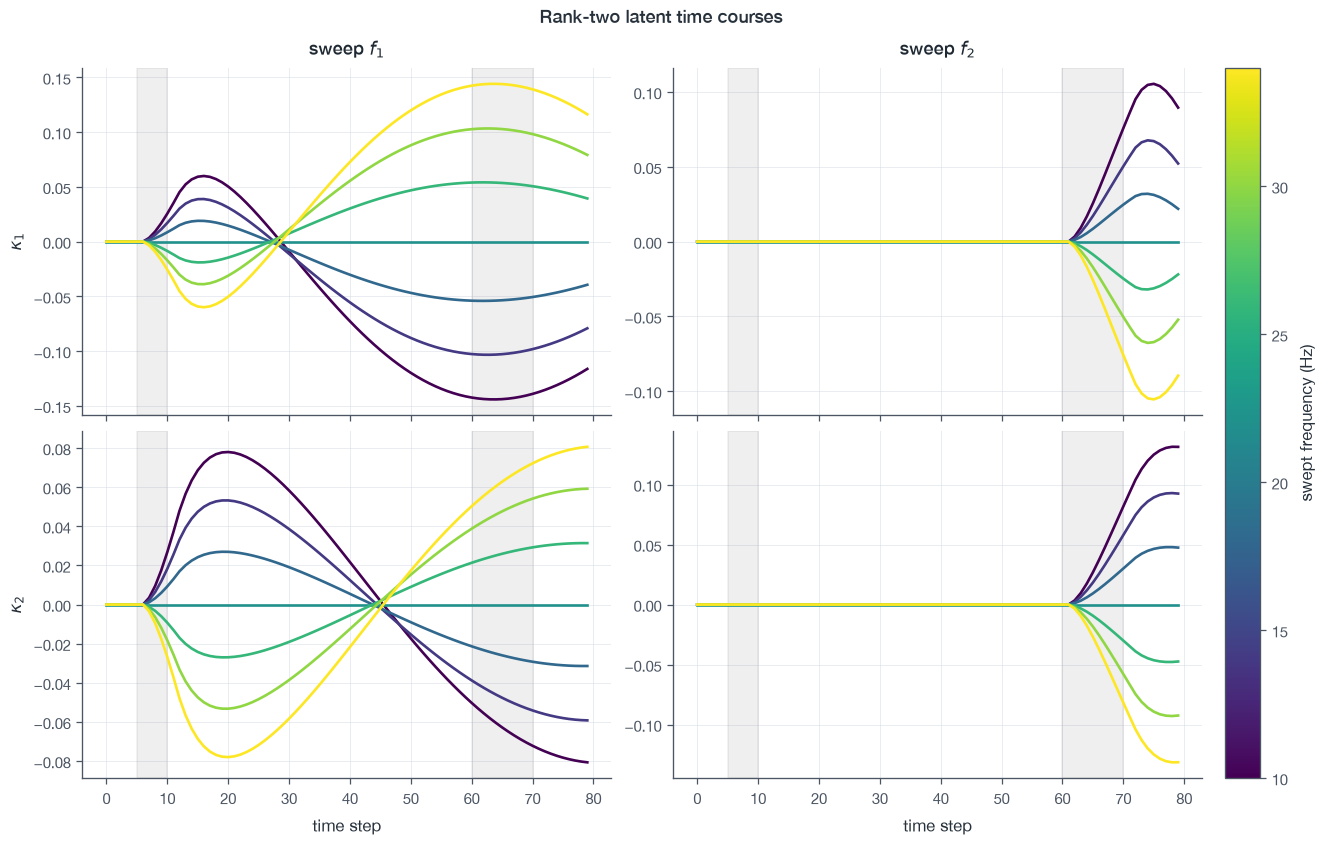

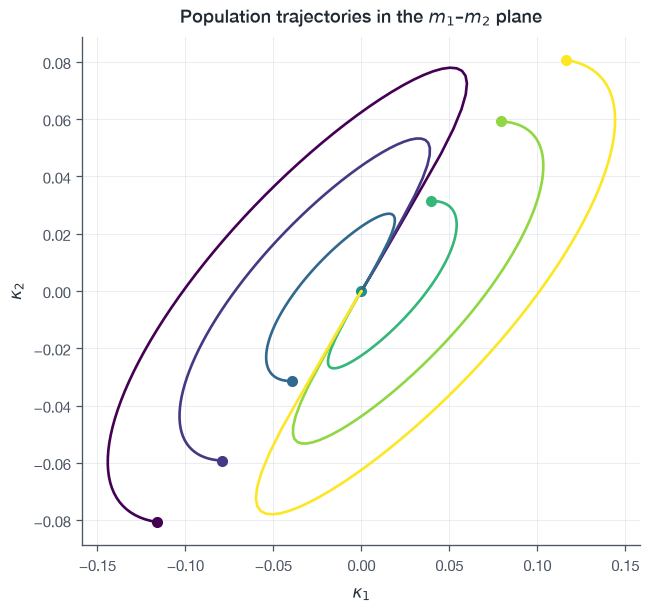

Median delay Jacobian eigenvalues (1/tau): [-0.021 -0.021]


In [14]:
neutral_frequency = FREQUENCY_CENTER
first_sweep_pairs = np.column_stack(
    (FREQUENCIES, np.full(len(FREQUENCIES), neutral_frequency))
)
second_sweep_pairs = np.column_stack(
    (np.full(len(FREQUENCIES), neutral_frequency), FREQUENCIES)
)

def canonical_coordinates(frequency_pairs):
    inputs, _ = make_memory_trials(frequency_pairs)
    outputs, states = run_model(memory_canonical, inputs)
    basis = np.column_stack(
        (
            memory_canonical.m.detach().numpy(),
            memory_canonical.I.detach().numpy(),
        )
    )
    coordinates = states @ np.linalg.pinv(basis).T
    return inputs, outputs, states, coordinates

(
    first_sweep_inputs,
    first_sweep_outputs,
    first_sweep_states,
    first_sweep_coordinates,
) = canonical_coordinates(first_sweep_pairs)
(
    second_sweep_inputs,
    second_sweep_outputs,
    second_sweep_states,
    second_sweep_coordinates,
) = canonical_coordinates(second_sweep_pairs)

color_norm = plt.Normalize(FREQUENCIES.min(), FREQUENCIES.max())
color_map = plt.get_cmap("viridis")
time_steps = np.arange(MEMORY_TRIAL_LENGTH)
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True, constrained_layout=True)
for column, (coordinates, title) in enumerate(
    (
        (first_sweep_coordinates, r"sweep $f_1$"),
        (second_sweep_coordinates, r"sweep $f_2$"),
    )
):
    for frequency, trajectory in zip(FREQUENCIES, coordinates):
        color = color_map(color_norm(frequency))
        axes[0, column].plot(time_steps, trajectory[:, 0], color=color)
        axes[1, column].plot(time_steps, trajectory[:, 1], color=color)
    axes[0, column].set_title(title)
    axes[1, column].set_xlabel("time step")
    for axis in axes[:, column]:
        axis.axvspan(*MEMORY_FIRST_WINDOW, color="gray", alpha=0.12)
        axis.axvspan(*MEMORY_SECOND_WINDOW, color="gray", alpha=0.12)
axes[0, 0].set_ylabel(r"$\kappa_1$")
axes[1, 0].set_ylabel(r"$\kappa_2$")
colorbar = fig.colorbar(
    plt.cm.ScalarMappable(norm=color_norm, cmap=color_map),
    ax=axes,
    pad=0.02,
)
colorbar.set_label("swept frequency (Hz)")
fig.suptitle("Rank-two latent time courses")
plt.show()

fig, axis = plt.subplots(figsize=(6, 5.5))
for frequency, trajectory in zip(FREQUENCIES, first_sweep_coordinates):
    axis.plot(
        trajectory[:, 0],
        trajectory[:, 1],
        color=color_map(color_norm(frequency)),
        label=f"{frequency:g}",
    )
    axis.scatter(*trajectory[-1, :2], color=color_map(color_norm(frequency)), s=32)
axis.set(
    xlabel=r"$\kappa_1$",
    ylabel=r"$\kappa_2$",
    title=r"Population trajectories in the $m_1$–$m_2$ plane",
)
plt.show()

delay_probe_states = first_sweep_states[:, MEMORY_SECOND_WINDOW[0] - 1]
delay_jacobian_eigenvalues = []
canonical_m_torch = memory_canonical.m.detach()
canonical_n_torch = memory_canonical.n.detach()
for state in torch.as_tensor(delay_probe_states):
    gain = 1 - torch.tanh(state).square()
    jacobian = (
        canonical_n_torch.T @ (gain[:, None] * canonical_m_torch) / NUM_UNITS
        - torch.eye(2)
    )
    delay_jacobian_eigenvalues.append(torch.linalg.eigvals(jacobian).numpy())
delay_jacobian_eigenvalues = np.asarray(delay_jacobian_eigenvalues)
median_delay_eigenvalues = np.median(
    np.sort(delay_jacobian_eigenvalues.real, axis=1),
    axis=0,
)[::-1]
print(
    "Median delay Jacobian eigenvalues (1/tau):",
    np.round(median_delay_eigenvalues, 3),
)

Both small-signal overlap eigenvalues form the complex pair
\(0.989\pm0.223i\), and both median delay-flow eigenvalues are about
\(-0.021/\tau\). Together with the curved phase portrait, this says that the
two coordinates are a coupled, slowly decaying rotation. The fixed-delay
network has learned a reliable timed trajectory; it has **not** recovered the
paper's clean, separately readable persistent and transient modes. Randomizing
the delay during training is the natural test that distinguishes those
mechanisms.

### 2.5 A separately readable persistent/transient comparison

The fixed-delay network above can solve the task with a timed rotation. For a
direct comparison, we trained a second \(N=128\), rank-two network with three
simple changes:

- \(f_1,f_2\) were sampled from every integer frequency from 10 to 34 Hz;
- the blank delay was randomized with a widening curriculum:
  25–50, then 25–75, then 25–100 steps (500–2000 ms);
- the initial loadings contained one near-critical pair and one leaky pair:
  \[
  n_1=m_1+0.5I,\qquad n_2=0.5m_2+1.9I,\qquad
  w=2.8m_1-2.2m_2+\text{independent residual}.
  \]

The next cell contains the complete training procedure. Each stage uses 640
trials, Adam with learning rate \(5\times10^{-3}\), batch size 32, and 12
epochs. Only \(m,n\) train; there is no covariance penalty and no saved
checkpoint. Seed 2032 makes both initialization and training reproducible.

This intentionally structured comparison shows that the readable mechanism
exists, not that random initialization naturally prefers it.


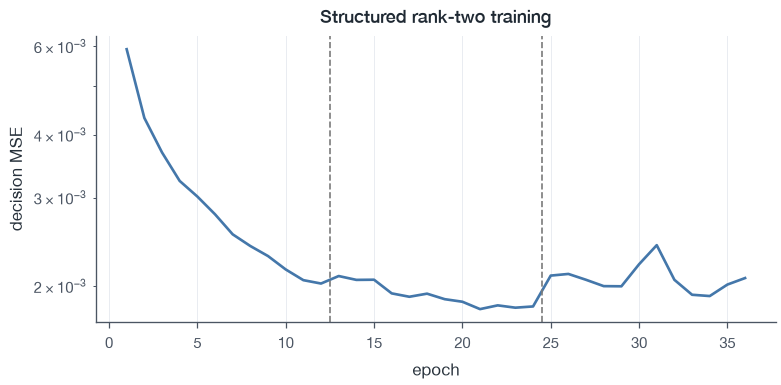

Final training MSE: 0.002075


In [15]:
from low_rank_rnn.data.variable_delay import (
    FIXATION_STEPS as VARIABLE_FIXATION_STEPS,
    STIMULUS_STEPS as VARIABLE_STIMULUS_STEPS,
    make_trials as make_variable_delay_trials,
)
from low_rank_rnn.training import masked_decision_loss, train_variable_delay

PERSISTENT_TRANSIENT_SEED = 2032
PERSISTENT_TRANSIENT_EPOCHS = 12
DENSE_FREQUENCIES = np.arange(10, 35)
DELAY_CURRICULUM = (
    np.arange(25, 51),
    np.arange(25, 76),
    np.arange(25, 101),
)


def initialize_persistent_transient_model(n_units, seed):
    '''Initialize one near-critical mode and one leaky mode.'''
    torch.manual_seed(seed)
    model = LowRankRNN(n_units, rank=2)
    basis = torch.linalg.qr(torch.randn(n_units, 4)).Q * np.sqrt(n_units)
    input_vector, persistent, transient, readout_residual = basis.T

    with torch.no_grad():
        model.I.copy_(input_vector)
        model.m.copy_(torch.column_stack((persistent, transient)))
        model.n.copy_(
            torch.column_stack(
                (persistent + 0.5 * input_vector, 0.5 * transient + 1.9 * input_vector)
            )
        )
        residual_gain = np.sqrt(16 - 2.8**2 - 2.2**2)
        model.w.copy_(2.8 * persistent - 2.2 * transient + residual_gain * readout_residual)
    return model


persistent_transient_model = initialize_persistent_transient_model(
    NUM_UNITS,
    PERSISTENT_TRANSIENT_SEED,
)
persistent_transient_losses = train_variable_delay(
    persistent_transient_model,
    DELAY_CURRICULUM,
    rng=np.random.default_rng(PERSISTENT_TRANSIENT_SEED),
    frequencies=DENSE_FREQUENCIES,
    num_trials=640,
    epochs_per_stage=PERSISTENT_TRANSIENT_EPOCHS,
    batch_size=32,
    learning_rate=5e-3,
    max_gradient_norm=1.0,
)

fig, axis = plt.subplots(figsize=(6.5, 3.2), constrained_layout=True)
axis.semilogy(np.arange(1, len(persistent_transient_losses) + 1), persistent_transient_losses)
for stage_end in (12, 24):
    axis.axvline(stage_end + 0.5, color=COLORS["gray"], linestyle="--", linewidth=1)
axis.set(xlabel="epoch", ylabel="decision MSE", title="Structured rank-two training")
plt.show()
print(f"Final training MSE: {persistent_transient_losses[-1]:.4g}")


In [16]:
# The real eigenvectors of C identify the slow and fast dynamical directions.
trained_m = persistent_transient_model.m.detach().numpy()
trained_n = persistent_transient_model.n.detach().numpy()
trained_overlap = connectivity_overlap(trained_m, trained_n)
overlap_values, overlap_vectors = np.linalg.eig(trained_overlap)
mode_order = np.argsort(-overlap_values.real)
overlap_values = overlap_values[mode_order]
overlap_vectors = overlap_vectors[:, mode_order].real
assert np.max(np.abs(overlap_values.imag)) < 1e-6

mode_m = trained_m @ overlap_vectors
mode_n = trained_n @ np.linalg.inv(overlap_vectors).T

# Fix the remaining scale/sign convention: each output mode has unit RMS and
# each input coupling is positive. The inverse rescaling preserves J exactly.
mode_scales = np.linalg.norm(mode_m, axis=0) / np.sqrt(NUM_UNITS)
mode_m = mode_m / mode_scales
mode_n = mode_n * mode_scales
mode_signs = np.sign(
    mode_n.T @ persistent_transient_model.I.detach().numpy()
)
mode_signs[mode_signs == 0] = 1
mode_m = mode_m * mode_signs
mode_n = mode_n * mode_signs

mode_overlap = connectivity_overlap(mode_m, mode_n)
mode_flow_eigenvalues = overlap_values.real - 1

probe_delays = np.array((25, 50, 75, 100))
persistent_transient_probe_mses = []
for delay in probe_delays:
    inputs, targets, decision_mask = make_variable_delay_trials(
        memory_grid_pairs,
        np.full(len(memory_grid_pairs), delay),
    )
    with torch.no_grad():
        outputs, _ = persistent_transient_model(inputs)
    persistent_transient_probe_mses.append(
        masked_decision_loss(outputs, targets, decision_mask).item()
    )
persistent_transient_probe_mses = np.asarray(persistent_transient_probe_mses)

# Check the nonlinear flow near the end of the longest blank delay.
local_probe_pairs = np.column_stack(
    (FREQUENCIES, np.full(len(FREQUENCIES), FREQUENCY_CENTER))
)
local_inputs, _, _ = make_variable_delay_trials(
    local_probe_pairs,
    np.full(len(local_probe_pairs), 100),
)
with torch.no_grad():
    _, local_states = persistent_transient_model(local_inputs)
local_step = VARIABLE_FIXATION_STEPS + VARIABLE_STIMULUS_STEPS + 100 - 1
local_flow_values = []
mode_m_tensor = torch.as_tensor(mode_m, dtype=torch.float32)
mode_n_tensor = torch.as_tensor(mode_n, dtype=torch.float32)
for state in local_states[:, local_step]:
    gain = 1 - torch.tanh(state).square()
    local_jacobian = (
        mode_n_tensor.T @ (gain[:, None] * mode_m_tensor) / NUM_UNITS
        - torch.eye(2)
    )
    values = torch.linalg.eigvals(local_jacobian)
    local_flow_values.append(values[torch.argsort(-values.real)].numpy())
local_flow_values = np.asarray(local_flow_values)

assert persistent_transient_probe_mses.max() < 5e-3
print("Loop gains:", np.round(overlap_values.real, 3))
print("Zero-state flow eigenvalues (1/tau):", np.round(mode_flow_eigenvalues, 3))
print(
    "Late-delay flow ranges (1/tau):",
    [
        tuple(
            np.round(
                (
                    local_flow_values[:, mode].real.min(),
                    local_flow_values[:, mode].real.max(),
                ),
                3,
            )
        )
        for mode in range(2)
    ],
)
print(
    "MSE at 500, 1000, 1500, 2000 ms:",
    np.round(persistent_transient_probe_mses, 4),
)


Loop gains: [ 1.011 -0.218]
Zero-state flow eigenvalues (1/tau): [ 0.011 -1.218]
Late-delay flow ranges (1/tau): [(np.float32(-0.028), np.float32(0.011)), (np.float32(-1.218), np.float32(-1.215))]
MSE at 500, 1000, 1500, 2000 ms: [0.0026 0.0027 0.003  0.0034]


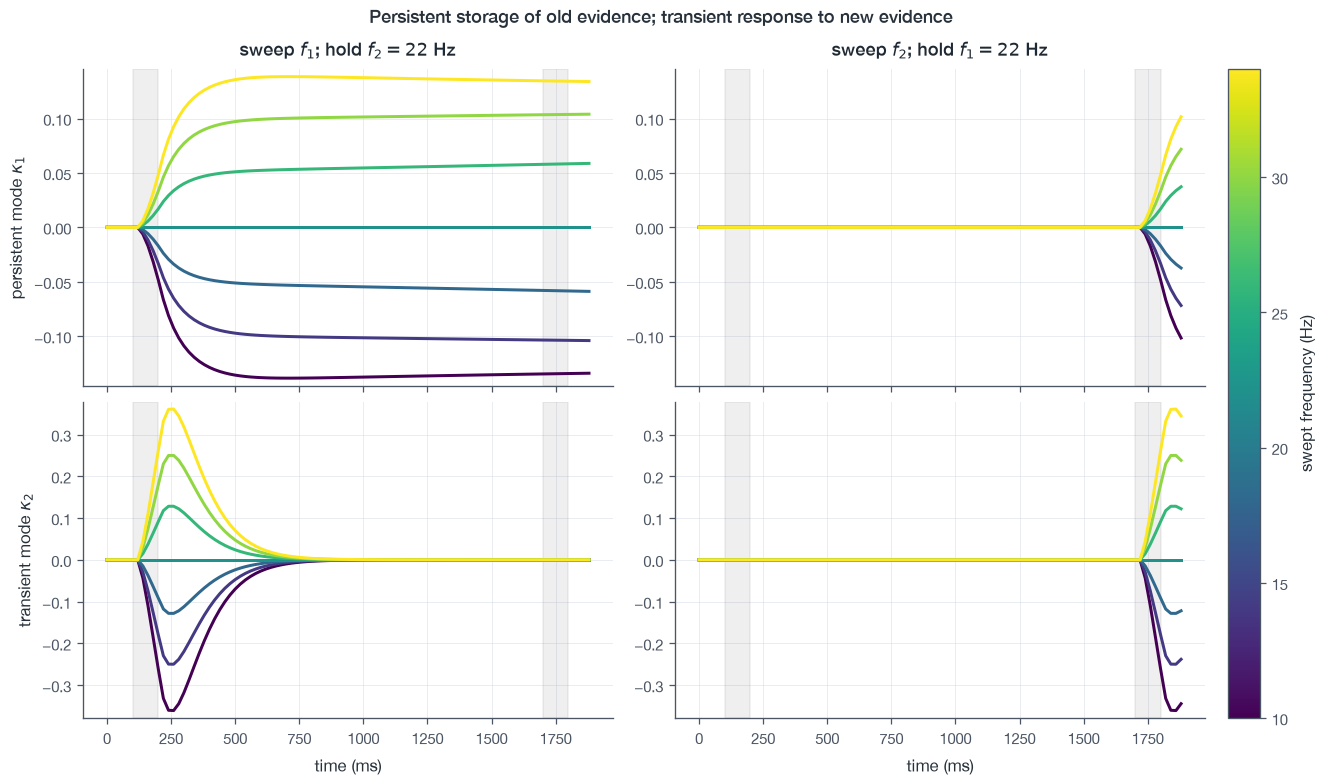

In [17]:
neutral_frequency = FREQUENCY_CENTER
persistent_transient_delay = 75
first_frequency_sweep = np.column_stack(
    (FREQUENCIES, np.full(len(FREQUENCIES), neutral_frequency))
)
second_frequency_sweep = np.column_stack(
    (np.full(len(FREQUENCIES), neutral_frequency), FREQUENCIES)
)

mode_state_basis = np.column_stack(
    (
        mode_m,
        persistent_transient_model.I.detach().numpy(),
    )
)
mode_state_inverse = np.linalg.pinv(mode_state_basis)


def mode_coordinates(frequency_pairs):
    inputs, _, _ = make_variable_delay_trials(
        frequency_pairs,
        np.full(len(frequency_pairs), persistent_transient_delay),
    )
    _, states = run_model(persistent_transient_model, inputs)
    return states @ mode_state_inverse.T


first_mode_coordinates = mode_coordinates(first_frequency_sweep)
second_mode_coordinates = mode_coordinates(second_frequency_sweep)

second_start = (
    VARIABLE_FIXATION_STEPS
    + VARIABLE_STIMULUS_STEPS
    + persistent_transient_delay
)
second_stop = second_start + VARIABLE_STIMULUS_STEPS
plot_stop = second_stop + 5
time_ms = 20 * np.arange(plot_stop)

frequency_norm = plt.Normalize(FREQUENCIES.min(), FREQUENCIES.max())
frequency_cmap = plt.get_cmap("viridis")
fig, axes = plt.subplots(
    2,
    2,
    figsize=(11, 6.5),
    sharex=True,
    constrained_layout=True,
)
for column, (coordinates, title) in enumerate(
    (
        (first_mode_coordinates, r"sweep $f_1$; hold $f_2=22$ Hz"),
        (second_mode_coordinates, r"sweep $f_2$; hold $f_1=22$ Hz"),
    )
):
    for frequency, trajectory in zip(FREQUENCIES, coordinates):
        color = frequency_cmap(frequency_norm(frequency))
        axes[0, column].plot(
            time_ms,
            trajectory[:plot_stop, 0],
            color=color,
            linewidth=1.8,
        )
        axes[1, column].plot(
            time_ms,
            trajectory[:plot_stop, 1],
            color=color,
            linewidth=1.8,
        )
    axes[0, column].set_title(title)
    axes[1, column].set_xlabel("time (ms)")
    for axis in axes[:, column]:
        axis.axvspan(
            20 * VARIABLE_FIXATION_STEPS,
            20 * (VARIABLE_FIXATION_STEPS + VARIABLE_STIMULUS_STEPS),
            color="gray",
            alpha=0.12,
        )
        axis.axvspan(
            20 * second_start,
            20 * second_stop,
            color="gray",
            alpha=0.12,
        )

for row in range(2):
    row_limit = 1.05 * max(
        np.abs(first_mode_coordinates[:, :plot_stop, row]).max(),
        np.abs(second_mode_coordinates[:, :plot_stop, row]).max(),
    )
    for axis in axes[row]:
        axis.set_ylim(-row_limit, row_limit)

axes[0, 0].set_ylabel(r"persistent mode $\kappa_1$")
axes[1, 0].set_ylabel(r"transient mode $\kappa_2$")
colorbar = fig.colorbar(
    plt.cm.ScalarMappable(norm=frequency_norm, cmap=frequency_cmap),
    ax=axes,
    pad=0.02,
)
colorbar.set_label("swept frequency (Hz)")
fig.suptitle("Persistent storage of old evidence; transient response to new evidence")
plt.show()


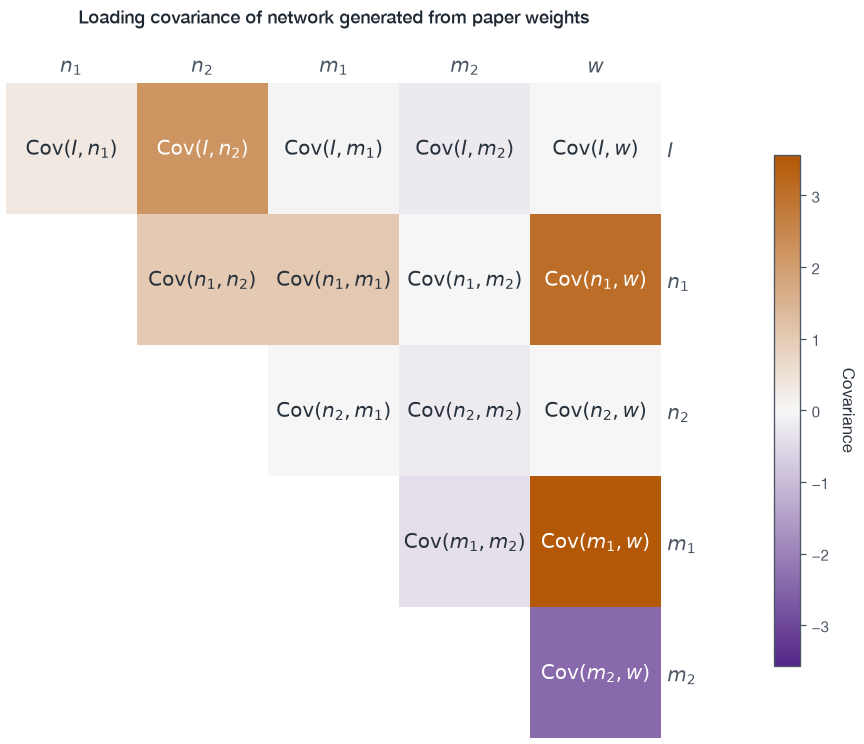

Recurrent overlap nᵀm/N:
 [[ 1.011 -0.   ]
 [-0.    -0.218]]
Input covariances [n₁, n₂]: [0.311 2.202]
Readout covariances [m₁, m₂]: [ 3.57  -2.407]


In [18]:
paper_weight_vectors = {
    "I": persistent_transient_model.I.detach().numpy(),
    "n_1": mode_n[:, 0],
    "n_2": mode_n[:, 1],
    "m_1": mode_m[:, 0],
    "m_2": mode_m[:, 1],
    "w": persistent_transient_model.w.detach().numpy(),
}
paper_weight_names = tuple(paper_weight_vectors)
_, paper_weight_covariance = fit_loading_gaussian(paper_weight_vectors)

figure, axis = plot_connectivity_covariance(
    paper_weight_names,
    paper_weight_covariance,
)
axis.set_title(
    "Loading covariance of network generated from paper weights",
    pad=18,
)
plt.show()

paper_weight_index = {
    name: index
    for index, name in enumerate(paper_weight_names)
}
print("Recurrent overlap nᵀm/N:\n", np.round(mode_overlap, 3))
print(
    "Input covariances [n₁, n₂]:",
    np.round(
        paper_weight_covariance[
            paper_weight_index["I"],
            [paper_weight_index["n_1"], paper_weight_index["n_2"]],
        ],
        3,
    ),
)
print(
    "Readout covariances [m₁, m₂]:",
    np.round(
        paper_weight_covariance[
            [paper_weight_index["m_1"], paper_weight_index["m_2"]],
            paper_weight_index["w"],
        ],
        3,
    ),
)

Random delays and dense frequencies remove the
fixed-delay shortcut; the structured initialization then converges to two
real, well-separated modes. The slow branch retains accumulated evidence,
whereas the fast branch loses the first stimulus and responds strongly to the
second. Input covariance gives both modes access to the stimulus, and the
opposite readout covariances combine stored and recent evidence as
\(f_1-f_2\)—without tracking the phase of an oscillation.


### 2.6 Test the six-dimensional Gaussian and two-dimensional circuit

We repeat the rank-one test in six-dimensional loading space
\((I,n_1,n_2,m_1,m_2,w)\): fit, resample, instantiate complete networks,
and score the full \(7\times7\) condition grid. The generic Gaussian
simulator from section 1.6 now produces two recurrent coordinates.

The handout also gives paper couplings

\[
\sigma_{n_1m_1}=1,\ \sigma_{n_2m_2}=0.5,\quad
\sigma_{n_1I}=0.5,\ \sigma_{n_2I}=1.9,\quad
\sigma_{m_1w}=2.8,\ \sigma_{m_2w}=-2.2.
\]

These numbers do not specify a complete positive-semidefinite Gaussian.
We therefore use them transparently as coefficients in the handout's
diagonal circuit, with unit state variances and all omitted cross-terms
set to zero. It is a qualitative reference, not a fitted reconstruction.

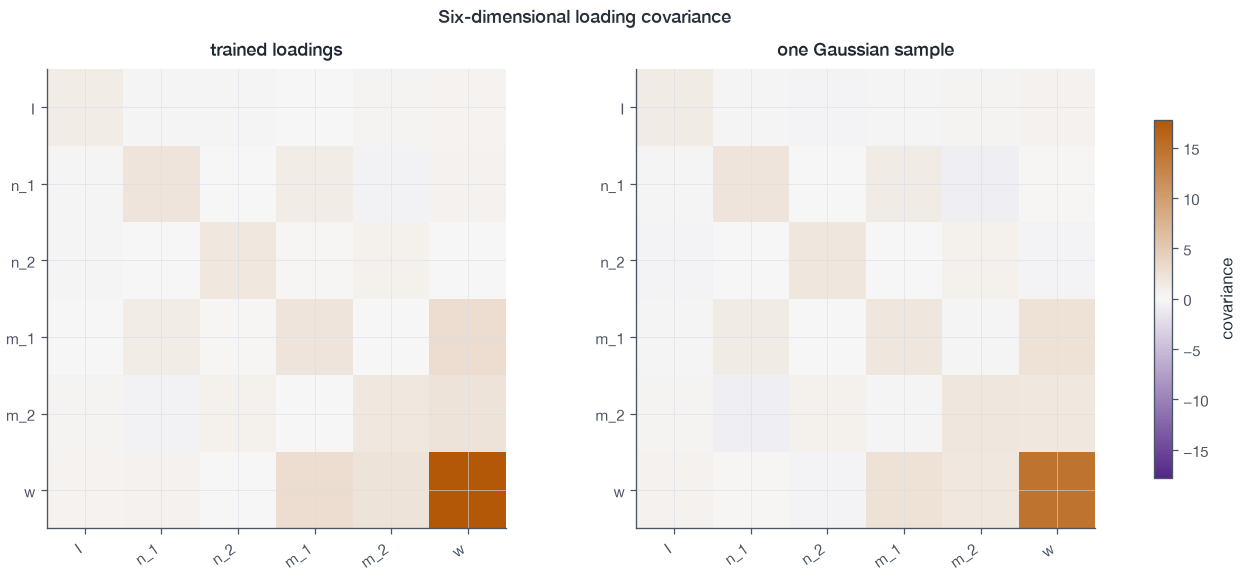

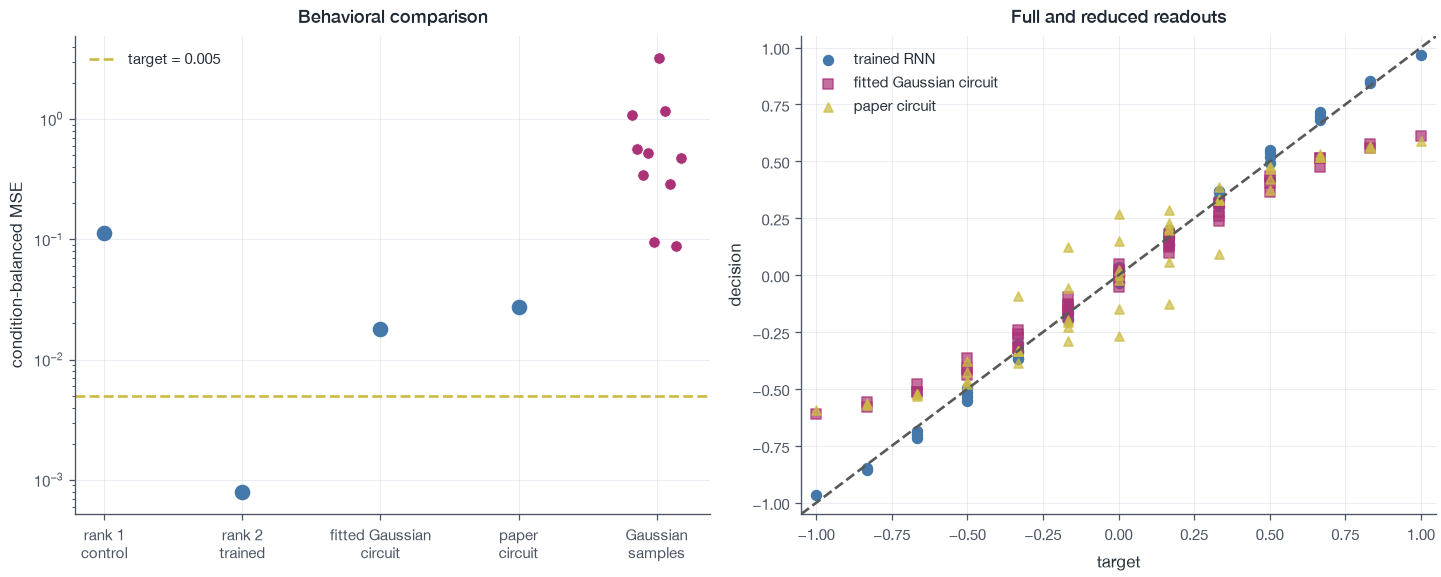

Fitted Gaussian-circuit MSE: 0.018029
Paper-coefficient circuit MSE: 0.027342
Gaussian-network MSE, median [range]: 0.5013 [0.0882, 3.2224]


In [19]:
memory_gaussian_rng = np.random.default_rng(BASE_SEED + 20)
memory_sampled_loadings = sample_loading_gaussian(
    memory_loading_mean,
    memory_loading_covariance,
    num_samples=NUM_UNITS,
    rng=memory_gaussian_rng,
)
memory_sampled_vectors = {
    name: memory_sampled_loadings[:, index]
    for index, name in enumerate(memory_names)
}
_, memory_sampled_covariance = fit_loading_gaussian(memory_sampled_vectors)

covariance_limit = max(
    float(np.max(np.abs(memory_loading_covariance))),
    float(np.max(np.abs(memory_sampled_covariance))),
)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), constrained_layout=True)
for axis, covariance, title in (
    (axes[0], memory_loading_covariance, "trained loadings"),
    (axes[1], memory_sampled_covariance, "one Gaussian sample"),
):
    image = axis.imshow(
        covariance,
        cmap=COVARIANCE_CMAP,
        norm=TwoSlopeNorm(
            vmin=-covariance_limit,
            vcenter=0,
            vmax=covariance_limit,
        ),
    )
    axis.set_xticks(range(len(memory_names)), labels=memory_names, rotation=35, ha="right")
    axis.set_yticks(range(len(memory_names)), labels=memory_names)
    axis.set_title(title)
fig.colorbar(image, ax=axes, label="covariance", shrink=0.78)
fig.suptitle("Six-dimensional loading covariance")
plt.show()

memory_sampled_networks = sample_low_rank_rnns(
    memory_names,
    memory_loading_mean,
    memory_loading_covariance,
    num_networks=10,
    num_neurons=NUM_UNITS,
    rng=np.random.default_rng(BASE_SEED + 21),
)
memory_sampled_mses = []
for network in memory_sampled_networks:
    outputs, _ = run_model(network, memory_grid_inputs)
    predictions = decision_values(outputs, MEMORY_DECISION_STEPS)
    mse, _ = regression_metrics(predictions, memory_grid_targets)
    memory_sampled_mses.append(mse)
memory_sampled_mses = np.asarray(memory_sampled_mses)

(
    memory_reduced_outputs,
    memory_reduced_kappa,
    memory_reduced_input,
) = simulate_gaussian_circuit(
    memory_grid_inputs,
    memory_names,
    memory_loading_mean,
    memory_loading_covariance,
    memory_canonical.step_size,
)
memory_reduced_decisions = decision_values(
    memory_reduced_outputs,
    MEMORY_DECISION_STEPS,
)
memory_reduced_mse, memory_reduced_r2 = regression_metrics(
    memory_reduced_decisions,
    memory_grid_targets,
)


def standard_gaussian_gain(delta):
    delta = np.atleast_1d(np.asarray(delta, dtype=float))
    rates = np.tanh(delta[:, None] * standard_normal_nodes)
    return (1 - rates**2) @ standard_normal_weights


def simulate_paper_rank_two_circuit(inputs, step_size):
    '''Diagonal two-mode circuit using the handout's supplied coefficients.'''
    inputs = np.asarray(inputs, dtype=float)
    batch_size, num_steps = inputs.shape
    kappa = np.zeros((batch_size, 2))
    filtered_input = np.zeros(batch_size)
    outputs = np.empty((batch_size, num_steps))
    recurrent_gain = np.array((1.0, 0.5))
    input_gain = np.array((0.5, 1.9))
    readout_gain = np.array((2.8, -2.2))

    for time in range(num_steps):
        delta = np.sqrt(np.sum(kappa**2, axis=1) + filtered_input**2)
        gain = standard_gaussian_gain(delta)
        outputs[:, time] = gain * (kappa @ readout_gain)
        recurrent_drive = gain[:, None] * (
            kappa * recurrent_gain + filtered_input[:, None] * input_gain
        )
        kappa += step_size * (-kappa + recurrent_drive)
        filtered_input += step_size * (
            -filtered_input + inputs[:, time]
        )
    return outputs


paper_circuit_outputs = simulate_paper_rank_two_circuit(
    memory_grid_inputs,
    memory_canonical.step_size,
)
paper_circuit_decisions = decision_values(
    paper_circuit_outputs,
    MEMORY_DECISION_STEPS,
)
paper_circuit_mse, paper_circuit_r2 = regression_metrics(
    paper_circuit_decisions,
    memory_grid_targets,
)

categories = (
    "rank 1\ncontrol",
    "rank 2\ntrained",
    "fitted Gaussian\ncircuit",
    "paper\ncircuit",
    "Gaussian\nsamples",
)
category_values = (
    memory_rank1_mse,
    memory_rank2_mse,
    memory_reduced_mse,
    paper_circuit_mse,
)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)
axes[0].scatter(
    np.arange(len(category_values)),
    category_values,
    color=COLORS["blue"],
    s=70,
    zorder=3,
)
sample_jitter = np.linspace(-0.18, 0.18, len(memory_sampled_mses))
axes[0].scatter(
    4 + sample_jitter,
    memory_sampled_mses,
    color=COLORS["purple"],
    edgecolor="white",
    linewidth=0.5,
    s=48,
    zorder=3,
)
axes[0].axhline(5e-3, color=COLORS["gold"], linestyle="--", label="target = 0.005")
axes[0].set_yscale("log")
axes[0].set_xticks(range(len(categories)), labels=categories)
axes[0].set(ylabel="condition-balanced MSE", title="Behavioral comparison")
axes[0].legend()

axes[1].scatter(
    memory_grid_targets,
    memory_grid_decisions,
    color=COLORS["blue"],
    s=34,
    label="trained RNN",
)
axes[1].scatter(
    memory_grid_targets,
    memory_reduced_decisions,
    color=COLORS["purple"],
    marker="s",
    s=30,
    alpha=0.7,
    label="fitted Gaussian circuit",
)
axes[1].scatter(
    memory_grid_targets,
    paper_circuit_decisions,
    color=COLORS["gold"],
    marker="^",
    s=30,
    alpha=0.7,
    label="paper circuit",
)
plot_limit = 1.05 * max(
    1.0,
    np.max(np.abs(memory_reduced_decisions)),
    np.max(np.abs(paper_circuit_decisions)),
)
axes[1].plot((-plot_limit, plot_limit), (-plot_limit, plot_limit), color="0.35", linestyle="--")
axes[1].set(
    xlim=(-plot_limit, plot_limit),
    ylim=(-plot_limit, plot_limit),
    xlabel="target",
    ylabel="decision",
    title="Full and reduced readouts",
)
axes[1].legend()
plt.show()

print(f"Fitted Gaussian-circuit MSE: {memory_reduced_mse:.6f}")
print(f"Paper-coefficient circuit MSE: {paper_circuit_mse:.6f}")
print(
    "Gaussian-network MSE, median [range]: "
    f"{np.median(memory_sampled_mses):.4f} "
    f"[{memory_sampled_mses.min():.4f}, {memory_sampled_mses.max():.4f}]"
)

## 3. Checks and takeaways

The table below is computed from the executed cells, so it is the compact
audit trail for the assignment thresholds and the two statistical reductions.

In [20]:
summary_table = f'''
| Task | Rank | Target | Decision window | Required threshold | Trained result | Gaussian resampling | Equivalent circuit |
|---|---:|---|---:|---:|---:|---:|---:|
| Perceptual decision | 1 | sign of evidence | 15 steps | loss < 0.05 | loss {rank1_losses[-1]:.2e}; accuracy {rank1_accuracy:.1%} | mean accuracy {rank1_sampled_accuracies.mean():.1%} | accuracy {rank1_reduced_accuracy:.1%} |
| Parametric memory | 2 | $(f_1-f_2)/24$ | 5 steps | MSE < 0.005 | MSE {memory_rank2_mse:.2e}; $R^2$ {memory_rank2_r2:.3f} | median MSE {np.median(memory_sampled_mses):.3f} | fitted MSE {memory_reduced_mse:.3f}; paper MSE {paper_circuit_mse:.3f} |
'''
display(Markdown(summary_table))

validation = {
    "rank1_training_threshold_met": rank1_losses[-1] < 5e-2,
    "rank2_evaluation_threshold_met": memory_rank2_mse < 5e-3,
    "persistent_transient_threshold_met": persistent_transient_probe_mses.max() < 5e-3,
    "persistent_transient_modes_are_real": np.max(np.abs(overlap_values.imag)) < 1e-6,
    "fixed_vectors_unchanged": bool(
        torch.equal(rank1_model.I, fixed_input_before)
        and torch.equal(rank1_model.w, fixed_readout_before)
    ),
    "rank2_svd_preserves_connectivity": connectivity_reconstruction_error < 1e-5,
    "rank1_fixed_points_verified": bool(
        len(fixed_points) >= 1
        and np.max(np.abs(rank1_flow(fixed_points))) < 1e-4
    ),
}
assert all(validation.values())
validation


| Task | Rank | Target | Decision window | Required threshold | Trained result | Gaussian resampling | Equivalent circuit |
|---|---:|---|---:|---:|---:|---:|---:|
| Perceptual decision | 1 | sign of evidence | 15 steps | loss < 0.05 | loss 8.79e-05; accuracy 100.0% | mean accuracy 99.6% | accuracy 100.0% |
| Parametric memory | 2 | $(f_1-f_2)/24$ | 5 steps | MSE < 0.005 | MSE 7.88e-04; $R^2$ 0.996 | median MSE 0.501 | fitted MSE 0.018; paper MSE 0.027 |


{'rank1_training_threshold_met': True,
 'rank2_evaluation_threshold_met': True,
 'persistent_transient_threshold_met': np.True_,
 'persistent_transient_modes_are_real': np.True_,
 'fixed_vectors_unchanged': True,
 'rank2_svd_preserves_connectivity': np.True_,
 'rank1_fixed_points_verified': True}

### Final interpretation

- **Rank one is enough for a sign decision.** Input–selection,
  recurrent-feedback, and recurrent–readout covariances create a
  categorical latent with stable choice states.
- **Rank two is needed for the comparison.** The matched rank-one control
  cannot keep the first value while independently processing the second.
  Here the two learned coordinates form a coupled, slowly decaying rotation,
  which is a timed solution rather than the paper's independent slow/fast
  mechanism.
- **Low rank is an exact geometric constraint here.** Rank-one activity
  stays in the \(m\)-\(I\) plane; rank-two activity stays in
  \(\operatorname{span}\{m_1,m_2,I\}\). PCA recovers this structure when
  the axes are unknown.
- **Gaussian theory is a hypothesis test, not a guarantee.** Covariance
  matching may preserve behavior, or finite-size sampling and non-Gaussian
  structure may matter. The trained, sampled, fitted-circuit, and
  paper-circuit scores make that distinction visible.
- **Task design and initialization select the mechanism.** The fixed-delay
  network uses a timed rotation; the structured randomized-delay comparison
  separates stored evidence from a rapidly decaying response. Two discrete attractors store a sign, whereas exact
  values require an approximately continuous line attractor.